# Import required libraries and build Spark Session

In [ ]:
# ============================================================================
# SECTION 1: IMPORT REQUIRED LIBRARIES
# ============================================================================

import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import warnings
warnings.filterwarnings('ignore')

In [2]:
spark_jars = os.environ.get("SPARK_JARS", "")
jar_list = spark_jars.split(",") if spark_jars else []
s3a_endpoint = os.environ.get("S3A_ENDPOINT", "-")
s3a_access_key = os.environ.get("S3A_ACCESS_KEY", "")
s3a_secret_key = os.environ.get("S3A_SECRET_KEY", "")
driver_memory = os.environ.get("SPARK_DRIVER_MEMORY", "4g")

spark = (
    SparkSession.builder
    .appName("Tazama-Dashboard")
    .master("local[*]")
    .config("spark.jars", spark_jars)
    .config("spark.driver.extraClassPath", ":".join(jar_list))
    .config("spark.executor.extraClassPath", ":".join(jar_list))
    .config("spark.hadoop.fs.s3a.endpoint", s3a_endpoint)
    .config("spark.hadoop.fs.s3a.access.key", s3a_access_key)
    .config("spark.hadoop.fs.s3a.secret.key", s3a_secret_key)
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.impl.disable.cache", "true")
    .config("spark.hadoop.fs.s3a.connection.maximum", "100")
    .config("spark.hadoop.fs.s3a.fast.upload", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryo.registrator", "org.apache.spark.HoodieSparkKryoRegistrar")
    .config("spark.sql.extensions", "org.apache.spark.sql.hudi.HoodieSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.hudi.catalog.HoodieCatalog")
    .config("spark.driver.memory", driver_memory)
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    .config("spark.memory.fraction", "0.8")
    .config("spark.memory.storageFraction", "0.2")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.advisoryPartitionSizeInBytes", "128mb")
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark Version: {spark.version}")

WAREHOUSE_ROOT = os.environ.get("WAREHOUSE_ROOT", "/opt/Tazama_Warehouse")


26/06/02 11:59:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/02 11:59:24 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/02 11:59:24 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/06/02 11:59:24 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/06/02 11:59:24 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/06/02 11:59:24 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
26/06/02 11:59:24 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.
26/06/02 11:59:24 WARN Utils: Service 'SparkUI' could not bind on port 4046. Attempting port 4047.
26/06/02 11:59:24 WARN Utils: Serv

Spark Version: 3.4.2


# Load Gold layer tables and make required metrics Dataframes

In [3]:
# SOURCE LAYER PATHS
gold_alerts_path       = f"{WAREHOUSE_ROOT}/gold/alerts"
cases_gold_path        = f"{WAREHOUSE_ROOT}/gold/cases"
tasks_gold_path        = f"{WAREHOUSE_ROOT}/gold/tasks"
transactions_gold_path = f"{WAREHOUSE_ROOT}/gold/transactions"

try:
    alerts = spark.read.format("hudi").load(gold_alerts_path)
    cases = spark.read.format("hudi").load(cases_gold_path)
    tasks = spark.read.format("hudi").load(tasks_gold_path)
    transactions = spark.read.format("hudi").load(transactions_gold_path)
    print("✓ All source tables loaded successfully")
except Exception as e:
    print(f"✗ Error loading tables: {e}")

✓ All source tables loaded successfully


In [4]:
# ============================================================================
# METRIC AGGREGATION UTILITY FUNCTIONS
# ============================================================================

def add_time_dimensions(df, timestamp_col="event_ts"):
    """
    Add standardized time dimensions to support multiple reporting granularities.
    Supports: hourly, daily, monthly, quarterly, annually
    """
    return df.withColumn(
        "metric_date", F.to_date(F.col(timestamp_col))
    ).withColumn(
        "metric_hour", F.date_format(F.col(timestamp_col), "yyyy-MM-dd HH:00:00")
    ).withColumn(
        "metric_day", F.date_format(F.col(timestamp_col), "yyyy-MM-dd")
    ).withColumn(
        "metric_month", F.date_format(F.col(timestamp_col), "yyyy-MM")
    ).withColumn(
        "metric_quarter", F.date_format(
            F.add_months(F.trunc(F.col(timestamp_col), "Q"), 0), "yyyy-Q"
        )
    ).withColumn(
        "metric_year", F.year(F.col(timestamp_col))
    )

In [5]:
def store_metric_gold_layer(df, output_path, metric_name, mode="overwrite"):
    """
    Store pre-aggregated metrics in gold layer with Hudi table format.
    Ensures consistency and efficiency for dashboard consumption.
    """
    try:
        hudi_options = {
            "hoodie.table.name": metric_name,
            "hoodie.datasource.write.operation": "upsert",
            "hoodie.datasource.write.precombine.field": "metric_ts",
            "hoodie.datasource.write.recordkey.field": "metric_id",
            "hoodie.datasource.write.partitionpath.field": "metric_date",
        }
        
        df.write \
            .format("hudi") \
            .mode(mode) \
            .options(**hudi_options) \
            .save(output_path)
        
        print(f"  ✓ {metric_name} stored at {output_path}")
        return True
    except Exception as e:
        print(f"  ✗ Error storing {metric_name}: {e}")
        return False

print("✓ Utility functions defined")

✓ Utility functions defined


In [6]:
print("="*80)
print("CASE MANAGEMENT METRICS")
print("="*80)

# ============================================================================
# 1. Cases created from alerts
# ============================================================================
cases_from_alerts = cases.filter(F.col("case_creation_type") == "AUTOMATIC_SYSTEM").count()

# ============================================================================
# 2. Cases manually created (no alert)
# ============================================================================
manual_cases = cases.filter(F.col("case_creation_type") != "AUTOMATIC_SYSTEM").count()
print(manual_cases)
# ============================================================================
# 3. Alerts (cases) automatically closed by ATM
# ============================================================================
# Auto-close conditions:
# 1. prediction_outcome_norm = FALSE_POSITIVE, OR
# 2. alert_type_norm = FRAUD AND prediction_outcome_norm = TRUE_POSITIVE AND transaction_status = BLOCKED

# Join alerts with transactions to get transaction status
alerts_with_tx_status = alerts.join(
    transactions.select(
        F.col("tx_msg_id"),
        F.col("tx_status").alias("transaction_status")
    ),
    "tx_msg_id",
    "left"
)

auto_closed_cases = alerts_with_tx_status.filter(
    (F.col("prediction_outcome_norm") == "FALSE_POSITIVE") |
    (
        (F.col("alert_type_norm") == "FRAUD") &
        (F.col("prediction_outcome_norm") == "TRUE_POSITIVE") &
        (F.col("transaction_status") == "BLOCKED")
    )
).select("case_id").distinct().count()

# ============================================================================
# 4. Auto-Closure Rate
# ============================================================================
total_alerts_generated = alerts.select("alert_id").distinct().count()
auto_closure_rate = (auto_closed_cases / total_alerts_generated * 100) if total_alerts_generated > 0 else 0

# ============================================================================
# 5. Auto-close cases reopened
# ============================================================================
auto_closed_case_ids = alerts_with_tx_status.filter(
    (F.col("prediction_outcome_norm") == "FALSE_POSITIVE") |
    (
        (F.col("alert_type_norm") == "FRAUD") &
        (F.col("prediction_outcome_norm") == "TRUE_POSITIVE") &
        (F.col("transaction_status") == "BLOCKED")
    )
).select("case_id").distinct()

auto_close_reopened = cases.join(auto_closed_case_ids, "case_id", "inner") \
    .filter(F.col("has_parent_case") == 1).count()

# ============================================================================
# 6. Auto-Closure Reopen Rate
# ============================================================================
auto_closure_reopen_rate = (auto_close_reopened / auto_closed_cases * 100) if auto_closed_cases > 0 else 0

# ============================================================================
# 7. Manual Case Rate
# ============================================================================
total_cases = cases.count()
manual_case_rate = (manual_cases / total_cases * 100) if total_cases > 0 else 0

# ============================================================================
# 8. Reopened Case Rate
# ============================================================================
cases_reopened = cases.filter(F.col("has_parent_case") == 1).count()
cases_closed = cases.filter(
    F.col("status").like("%CLOSED%") | 
    F.col("status").like("%COMPLETE%") |
    F.col("status").like("%DISPOSED%")
).count()
reopened_case_rate = (cases_reopened / cases_closed * 100) if cases_closed > 0 else 0

# ============================================================================
# 9, 10, 11. AML, Fraud, and Fraud+AML cases
# ============================================================================
cases_with_type = cases.join(
    alerts.select("case_id", "alert_type_norm").distinct(),
    "case_id",
    "left"
)

aml_cases = cases_with_type.filter(F.col("alert_type_norm") == "AML") \
    .select("case_id").distinct().count()
fraud_cases = cases_with_type.filter(F.col("alert_type_norm") == "FRAUD") \
    .select("case_id").distinct().count()
fraud_aml_cases = cases_with_type.filter(F.col("alert_type_norm") == "FRAUD_AND_AML") \
    .select("case_id").distinct().count()

# ============================================================================
# 12. Open investigations
# ============================================================================
open_investigations = cases.join(
    tasks.filter(
        F.col("status") == "STATUS_20_IN_PROGRESS"
    ).select("case_id").distinct(),
    "case_id",
    "inner"
).select("case_id").distinct().count()

# ============================================================================
# 13. Investigation tasks by status
# ============================================================================
investigation_tasks_by_status = tasks.filter(
    F.col("status") == "STATUS_20_IN_PROGRESS"
).groupBy("status").agg(
    F.count("task_id").alias("task_count")
).orderBy(F.desc("task_count"))

# ============================================================================
# 14. Investigation Conversion Rate
# ============================================================================
cases_with_investigate_task = cases.join(
    tasks.filter(
        F.col("status") == "STATUS_20_IN_PROGRESS"
    ).select("case_id").distinct(),
    "case_id",
    "inner"
).select("case_id").distinct().count()

investigation_conversion_rate = (cases_with_investigate_task / cases_from_alerts * 100) \
    if cases_from_alerts > 0 else 0

# ============================================================================
# 15. Cases closed
# ============================================================================
# Already calculated as cases_closed above

# ============================================================================
# 16. Cases by status & disposition
# ============================================================================
cases_by_status = cases.groupBy("status").agg(
    F.count("case_id").alias("case_count")
).orderBy(F.desc("case_count"))

# Cases by disposition (using actual case status codes)
confirmed_cases = cases.filter(
    F.col("status") == "STATUS_82_CLOSED_CONFIRMED"
).select("case_id").distinct().count()

refuted_cases = cases.filter(
    F.col("status") == "STATUS_81_CLOSED_REFUTED"
).select("case_id").distinct().count()

inconclusive_cases = cases.filter(
    F.col("status") == "STATUS_83_CLOSED_INCONCLUSIVE"
).select("case_id").distinct().count()

# ============================================================================
# 17. Tasks metrics
# ============================================================================
open_tasks = tasks.filter(F.col("is_completed") == 0).count()

tasks_by_status = tasks.groupBy("status").agg(
    F.count("task_id").alias("task_count")
).orderBy(F.desc("task_count"))

open_tasks_by_type = tasks.filter(F.col("is_completed") == 0).groupBy("candidate_group").agg(
    F.count("task_id").alias("task_count")
).orderBy(F.desc("task_count"))

# ============================================================================
# 18. SAR/STR filed - NOT AVAILABLE in current schema
# ============================================================================
sar_str_filed = "N/A - Field not available"

# ============================================================================
# 19 & 20. Case to Disposition Time / MTTD
# ============================================================================
cases_with_duration = cases.filter(F.col("created_to_updated_ms") > 0)
avg_case_duration_ms = cases_with_duration.agg(F.avg("created_to_updated_ms")).collect()[0][0]
mttd_hours = (avg_case_duration_ms / (1000 * 60 * 60)) if avg_case_duration_ms else 0
mttd_days = mttd_hours / 24

# ============================================================================
# 21. MTTD by disposition
# ============================================================================
mttd_by_disposition = cases.join(
    alerts.select("case_id", "prediction_outcome_norm").distinct(),
    "case_id",
    "left"
).filter(
    F.col("created_to_updated_ms") > 0
).groupBy("prediction_outcome_norm").agg(
    F.avg("created_to_updated_ms").alias("avg_duration_ms"),
    F.count("case_id").alias("case_count"))
mttd_by_disposition = cases.filter(
    (F.col("created_to_updated_ms") > 0) &
    F.col("status").isin(
        "STATUS_81_CLOSED_REFUTED",
        "STATUS_82_CLOSED_CONFIRMED",
        "STATUS_83_CLOSED_INCONCLUSIVE"
    )
).groupBy("status").agg(
    F.avg("created_to_updated_ms").alias("avg_duration_ms"),
    F.count("case_id").alias("case_count")
).withColumn(
    "avg_duration_hours",
    F.round(F.col("avg_duration_ms") / (1000 * 60 * 60), 2)
).select("status", "case_count", "avg_duration_hours") \
 .orderBy("status")

# ============================================================================
# 22. Confirmation Rate
# ============================================================================
confirmation_rate = (confirmed_cases / cases_closed * 100) if cases_closed > 0 else 0

# ============================================================================
# 23. Case Closure Rate per investigator
# ============================================================================
cases_with_owner = cases.filter(F.col("has_owner") == 1).count()

cases_per_owner = cases.filter(F.col("case_owner_user_id").isNotNull()) \
    .groupBy("case_owner_user_id").agg(
        F.count("case_id").alias("total_cases"),
        F.sum(F.when(
            F.col("status").like("%CLOSED%") | F.col("status").like("%COMPLETE%"), 
            1
        ).otherwise(0)).alias("closed_cases")
    ).withColumn(
        "closure_rate_pct",
        F.round((F.col("closed_cases") / F.col("total_cases")) * 100, 2)
    ).orderBy(F.desc("total_cases"))

print("    Case metrics calculation complete!")
print(f"   Total cases analyzed: {total_cases}")
print(f"   Total alerts analyzed: {total_alerts_generated}")

CASE MANAGEMENT METRICS


44


    Case metrics calculation complete!
   Total cases analyzed: 220
   Total alerts analyzed: 285


In [7]:
# Create Case Metrics Summary DataFrame
case_metrics_df = pd.DataFrame({
    "Metric": [
        "1. Cases from Alerts",
        "2. Manual Cases",
        "3. Auto-Closed Cases",
        "4. Auto-Closure Rate (%)",
        "5. Auto-Close Reopened",
        "6. Auto-Closure Reopen Rate (%)",
        "7. Manual Case Rate (%)",
        "8. Reopened Case Rate (%)",
        "9. AML Cases",
        "10. Fraud Cases",
        "11. Fraud & AML Cases",
        "12. Open Investigations",
        "14. Investigation Conversion Rate (%)",
        "15. Cases Closed",
        "16a. Confirmed Cases (Closed)",
        "16b. Refuted Cases (Closed)",
        "16c. Inconclusive Cases (Closed)",
        "17. Open Tasks",
        "19-20. MTTD (hours)",
        "22. Confirmation Rate (%)",
        "23. Cases with Owner"
    ],
    "Value": [
        cases_from_alerts,
        manual_cases,
        auto_closed_cases,
        round(auto_closure_rate, 2),
        auto_close_reopened,
        round(auto_closure_reopen_rate, 2),
        round(manual_case_rate, 2),
        round(reopened_case_rate, 2),
        aml_cases,
        fraud_cases,
        fraud_aml_cases,
        open_investigations,
        round(investigation_conversion_rate, 2),
        cases_closed,
        confirmed_cases,
        refuted_cases,
        inconclusive_cases,
        open_tasks,
        round(mttd_hours, 2),
        round(confirmation_rate, 2),
        cases_with_owner
    ]
})

print("\n" + "="*80)
print("CASE METRICS SUMMARY")
print("="*80)
print(case_metrics_df.to_string(index=False))

print("\n" + "="*80)
print("DETAILED BREAKDOWNS")
print("="*80)

print("\n13. Investigation Tasks by Status:")
investigation_tasks_by_status.show(truncate=False)

print("\n16. Cases by Status:")
cases_by_status.show(truncate=False)

print("\n17a. Tasks by Status:")
tasks_by_status.show(truncate=False)

print("\n17b. Open Tasks by Type:")
open_tasks_by_type.show(truncate=False)

print("\n21. MTTD by Disposition:")
mttd_by_disposition.show(truncate=False)

print("\n23. Case Closure Rate per Investigator:")
cases_per_owner.show(10, truncate=False)

print("\n" + "="*80)
print("MISSING METRICS")
print("="*80)
print(f"18. SAR/STR Filed: {sar_str_filed}")
print("="*80)


CASE METRICS SUMMARY
                               Metric  Value
                 1. Cases from Alerts 176.00
                      2. Manual Cases  44.00
                 3. Auto-Closed Cases   0.00
             4. Auto-Closure Rate (%)   0.00
               5. Auto-Close Reopened   0.00
      6. Auto-Closure Reopen Rate (%)   0.00
              7. Manual Case Rate (%)  20.00
            8. Reopened Case Rate (%)  70.59
                         9. AML Cases   4.00
                      10. Fraud Cases   1.00
                11. Fraud & AML Cases   0.00
              12. Open Investigations  33.00
14. Investigation Conversion Rate (%)  18.75
                     15. Cases Closed  17.00
        16a. Confirmed Cases (Closed)   8.00
          16b. Refuted Cases (Closed)   6.00
     16c. Inconclusive Cases (Closed)   2.00
                       17. Open Tasks 256.00
                  19-20. MTTD (hours)  61.38
            22. Confirmation Rate (%)  47.06
                 23. Cases with O

In [8]:
# ============================================================================
# SECTION 2.3: CASE METRICS - GOLD LAYER
# Pre-Aggregated at Multiple Granularities (Hourly, Daily, Monthly, Quarterly, Annually)
# ============================================================================

print("\n" + "="*80)
print("2.3 CASE METRICS - GOLD LAYER")
print("="*80)

# Prepare cases with time dimensions
cases_with_time = add_time_dimensions(cases, timestamp_col="case_created_ts")
tasks_with_time = add_time_dimensions(tasks, timestamp_col="task_created_ts")

# METRIC 1: Cases created from alerts (automatic)
cases_from_alerts_daily = cases_with_time.filter(
    F.col("case_creation_type") == "AUTOMATIC_SYSTEM"
).groupBy("metric_date").agg(
    F.count("case_id").alias("cases_from_alerts")
)

# METRIC 2: Manually created cases
manual_cases_daily = cases_with_time.filter(
    F.col("case_creation_type") != "AUTOMATIC_SYSTEM"
).groupBy("metric_date").agg(
    F.count("case_id").alias("manual_cases_created")
)

# METRIC 3 & 4: Auto-closed cases and auto-closure rate
auto_closed_cases = cases_with_time.filter(
    (F.col("status").like("%CLOSED%") | F.col("status").like("%AUTO%"))
).groupBy("metric_date").agg(
    F.count("case_id").alias("auto_closed_cases")
)

# METRIC 5: Auto-closure reopened
auto_closed_reopened = cases_with_time.filter(
    (F.col("status").like("%CLOSED%")) & (F.col("has_parent_case") == 1)
).groupBy("metric_date").agg(
    F.count("case_id").alias("auto_closed_reopened")
)

# METRIC 6: Reopened case rate
cases_reopened = cases_with_time.filter(
    F.col("has_parent_case") == 1
).groupBy("metric_date").agg(
    F.count("case_id").alias("cases_reopened")
)

cases_closed_total = cases_with_time.filter(
    F.col("status").like("%CLOSED%") | F.col("status").like("%COMPLETE%")
).groupBy("metric_date").agg(
    F.count("case_id").alias("total_cases_closed")
)

# METRIC 7: Manual case rate
total_cases_daily = cases_with_time.groupBy("metric_date").agg(
    F.count("case_id").alias("total_cases_created")
)

# METRIC 9, 10, 11: AML, Fraud, and combined cases
cases_with_alert_type = cases_with_time.join(
    alerts.select("case_id", "alert_type_norm").distinct(),
    "case_id",
    "left"
)

aml_cases_daily = cases_with_alert_type.filter(
    F.col("alert_type_norm") == "AML"
).groupBy("metric_date").agg(
    F.countDistinct("case_id").alias("aml_cases")
)

fraud_cases_daily = cases_with_alert_type.filter(
    F.col("alert_type_norm") == "FRAUD"
).groupBy("metric_date").agg(
    F.countDistinct("case_id").alias("fraud_cases")
)

fraud_aml_cases_daily = cases_with_alert_type.filter(
    F.col("alert_type_norm") == "FRAUD_AND_AML"
).groupBy("metric_date").agg(
    F.countDistinct("case_id").alias("fraud_aml_cases")
)

# METRIC 12: Open investigations
open_investigations_daily = cases_with_time.join(
    tasks_with_time.filter(F.col("status") == "STATUS_20_IN_PROGRESS").select("case_id").distinct(),
    "case_id",
    "inner"
).groupBy("metric_date").agg(
    F.countDistinct("case_id").alias("cases_with_open_investigations")
)

# METRIC 13: Investigation tasks by status
investigation_tasks_by_status = tasks_with_time.groupBy("metric_date", "status").agg(
    F.count("task_id").alias("task_count")
)

# METRIC 14: Investigation conversion rate (placeholder)
cases_with_investigate = cases_with_time.join(
    tasks_with_time.filter(F.col("status") == "STATUS_20_IN_PROGRESS").select("case_id").distinct(),
    "case_id",
    "inner"
).groupBy("metric_date").agg(
    F.count("case_id").alias("cases_with_investigate_tasks")
)

# METRIC 15: Cases closed (already calculated)
# METRIC 16: Cases by status
cases_by_status = cases_with_time.groupBy("metric_date", "status").agg(
    F.count("case_id").alias("case_count")
)

# METRIC 16a, 16b, 16c: Cases by disposition
confirmed_cases = cases_with_time.filter(
    F.col("status") == "STATUS_82_CLOSED_CONFIRMED"
).groupBy("metric_date").agg(
    F.count("case_id").alias("confirmed_cases")
)

refuted_cases = cases_with_time.filter(
    F.col("status") == "STATUS_81_CLOSED_REFUTED"
).groupBy("metric_date").agg(
    F.count("case_id").alias("refuted_cases")
)

inconclusive_cases = cases_with_time.filter(
    F.col("status") == "STATUS_83_CLOSED_INCONCLUSIVE"
).groupBy("metric_date").agg(
    F.count("case_id").alias("inconclusive_cases")
)

# METRIC 17: Open tasks
open_tasks_daily = tasks_with_time.filter(
    F.col("is_completed") == 0
).groupBy("metric_date").agg(
    F.count("task_id").alias("open_tasks")
)

# METRIC 17b: Open tasks by type
open_tasks_by_type = tasks_with_time.filter(
    F.col("is_completed") == 0
).groupBy("metric_date", "candidate_group").agg(
    F.count("task_id").alias("open_task_count")
)

# METRIC 19 & 20: Case Duration (MTTD)
cases_with_duration = cases_with_time.filter(
    F.col("created_to_updated_ms") > 0
).groupBy("metric_date").agg(
    F.avg("created_to_updated_ms").alias("avg_case_duration_ms"),
    F.count("case_id").alias("cases_with_duration")
).withColumn(
    "avg_mttd_hours",
    F.round(F.col("avg_case_duration_ms") / (1000 * 60 * 60), 2)
).withColumn(
    "avg_mttd_days",
    F.round(F.col("avg_case_duration_ms") / (1000 * 60 * 60 * 24), 2)
)

# METRIC 22: Confirmation rate
# METRIC 23: Case closure rate per investigator
cases_per_investigator = cases_with_time.filter(
    F.col("case_owner_user_id").isNotNull()
).groupBy("metric_date", "case_owner_user_id").agg(
    F.count("case_id").alias("total_cases_owner"),
    F.sum(F.when(F.col("status").like("%CLOSED%"), 1).otherwise(0)).alias("closed_cases_owner")
).withColumn(
    "investigator_closure_rate_pct",
    F.round((F.col("closed_cases_owner") / F.col("total_cases_owner")) * 100, 2)
)

# Combine all case metrics
case_metrics_daily = total_cases_daily.join(
    cases_from_alerts_daily, "metric_date", "left"
).join(
    manual_cases_daily, "metric_date", "left"
).join(
    auto_closed_cases, "metric_date", "left"
).join(
    auto_closed_reopened, "metric_date", "left"
).join(
    cases_reopened, "metric_date", "left"
).join(
    cases_closed_total, "metric_date", "left"
).join(
    aml_cases_daily, "metric_date", "left"
).join(
    fraud_cases_daily, "metric_date", "left"
).join(
    fraud_aml_cases_daily, "metric_date", "left"
).join(
    open_investigations_daily, "metric_date", "left"
).join(
    cases_with_investigate, "metric_date", "left"
).join(
    confirmed_cases, "metric_date", "left"
).join(
    refuted_cases, "metric_date", "left"
).join(
    inconclusive_cases, "metric_date", "left"
).join(
    open_tasks_daily, "metric_date", "left"
).join(
    cases_with_duration, "metric_date", "left"
).fillna(0)

# Add calculated rates
case_metrics_daily = case_metrics_daily.withColumn(
    "auto_closure_rate_pct",
    F.when(
        F.col("cases_from_alerts") > 0,
        F.round((F.col("auto_closed_cases") / F.col("cases_from_alerts")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "auto_closure_reopen_rate_pct",
    F.when(
        F.col("auto_closed_cases") > 0,
        F.round((F.col("auto_closed_reopened") / F.col("auto_closed_cases")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "manual_case_rate_pct",
    F.when(
        F.col("total_cases_created") > 0,
        F.round((F.col("manual_cases_created") / F.col("total_cases_created")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "reopened_case_rate_pct",
    F.when(
        F.col("total_cases_closed") > 0,
        F.round((F.col("cases_reopened") / F.col("total_cases_closed")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "investigation_conversion_rate_pct",
    F.when(
        F.col("cases_from_alerts") > 0,
        F.round((F.col("cases_with_investigate_tasks") / F.col("cases_from_alerts")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "confirmation_rate_pct",
    F.when(
        F.col("total_cases_closed") > 0,
        F.round((F.col("confirmed_cases") / F.col("total_cases_closed")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "metric_ts", F.lit(datetime.now())
)

print("\n✓ Case Metrics Calculated (23 metrics):")
for i, metric in enumerate([
    "Cases from Alerts",
    "Manually Created Cases",
    "Auto-Closed Cases",
    "Auto-Closure Rate",
    "Auto-Closure Reopened",
    "Auto-Closure Reopen Rate",
    "Manual Case Rate",
    "Reopened Case Rate",
    "AML Cases",
    "Fraud Cases",
    "Fraud & AML Cases",
    "Open Investigations",
    "Investigation Tasks by Status",
    "Investigation Conversion Rate",
    "Cases Closed",
    "Cases by Status",
    "Confirmed Cases",
    "Refuted Cases",
    "Inconclusive Cases",
    "Open Tasks",
    "Tasks by Status",
    "Case Duration (MTTD)",
    "Case Closure Rate per Investigator"
], 1):
    print(f"  Metric {i}: {metric}")

# Display sample data
print("\nSample Case Metrics (Daily Granularity):")
case_metrics_daily.select(
    "metric_date", "total_cases_created", "cases_from_alerts", "manual_cases_created",
    "auto_closed_cases", "auto_closure_rate_pct", "confirmed_cases", "avg_mttd_days"
).limit(10).show(truncate=False)


2.3 CASE METRICS - GOLD LAYER

✓ Case Metrics Calculated (23 metrics):
  Metric 1: Cases from Alerts
  Metric 2: Manually Created Cases
  Metric 3: Auto-Closed Cases
  Metric 4: Auto-Closure Rate
  Metric 5: Auto-Closure Reopened
  Metric 6: Auto-Closure Reopen Rate
  Metric 7: Manual Case Rate
  Metric 8: Reopened Case Rate
  Metric 9: AML Cases
  Metric 10: Fraud Cases
  Metric 11: Fraud & AML Cases
  Metric 12: Open Investigations
  Metric 13: Investigation Tasks by Status
  Metric 14: Investigation Conversion Rate
  Metric 15: Cases Closed
  Metric 16: Cases by Status
  Metric 17: Confirmed Cases
  Metric 18: Refuted Cases
  Metric 19: Inconclusive Cases
  Metric 20: Open Tasks
  Metric 21: Tasks by Status
  Metric 22: Case Duration (MTTD)
  Metric 23: Case Closure Rate per Investigator

Sample Case Metrics (Daily Granularity):
+-----------+-------------------+-----------------+--------------------+-----------------+---------------------+---------------+-------------+
|metric_date

In [9]:
# ============================================================================
# SECTION 2.4: FRAUD METRICS - GOLD LAYER
# Pre-Aggregated at Multiple Granularities (Hourly, Daily, Monthly, Quarterly, Annually)
# ============================================================================

print("\n" + "="*80)
print("2.4 FRAUD METRICS - GOLD LAYER")
print("="*80)

# PREREQUISITE: Define variables from TMS and Alert sections if not already defined
# ============================================================================
if 'tx_with_time' not in locals():
    tx_with_time = add_time_dimensions(transactions, timestamp_col="ingested_at_ts")
    
if 'tx_evaluated' not in locals():
    tx_evaluated = tx_with_time.join(
        alerts.select("tx_msg_id").distinct(),
        tx_with_time.tx_msg_id == alerts.tx_msg_id,
        "inner"
    ).select(tx_with_time["*"])
    
if 'alerts_with_time' not in locals():
    alerts_with_time = add_time_dimensions(alerts, timestamp_col="created_at_ts")
    
if 'cases_with_time' not in locals():
    cases_with_time = add_time_dimensions(cases, timestamp_col="case_created_ts")

# Join all relevant tables
fraud_base = cases_with_time.join(
    alerts.select("case_id", "alert_type_norm", "prediction_outcome_norm", "tx_msg_id").distinct(),
    "case_id",
    "left"
).join(
    transactions.select("tx_msg_id", "tx_amount", "tx_status", "event_ts"),
    "tx_msg_id",
    "left"
)

# METRIC 1-3: Case outcomes by disposition
confirmed_fraud_daily = fraud_base.filter(
    F.col("status") == "STATUS_82_CLOSED_CONFIRMED"
).groupBy("metric_date").agg(
    F.count("case_id").alias("confirmed_cases"),
    F.sum(F.when(F.col("tx_amount").isNotNull(), F.col("tx_amount")).otherwise(0)).alias("confirmed_fraud_value")
)

refuted_fraud_daily = fraud_base.filter(
    F.col("status") == "STATUS_81_CLOSED_REFUTED"
).groupBy("metric_date").agg(
    F.count("case_id").alias("refuted_cases")
)

inconclusive_fraud_daily = fraud_base.filter(
    F.col("status") == "STATUS_83_CLOSED_INCONCLUSIVE"
).groupBy("metric_date").agg(
    F.count("case_id").alias("inconclusive_cases")
)

# METRIC 4-6: Detection accuracy using predictions
tp_from_alerts = fraud_base.filter(
    F.col("prediction_outcome_norm") == "TRUE_POSITIVE"
).groupBy("metric_date").agg(
    F.countDistinct("case_id").alias("true_positives")
)

fp_from_alerts = fraud_base.filter(
    F.col("prediction_outcome_norm") == "FALSE_POSITIVE"
).groupBy("metric_date").agg(
    F.countDistinct("case_id").alias("false_positives")
)

fn_from_alerts = fraud_base.filter(
    F.col("prediction_outcome_norm") == "FALSE_NEGATIVE"
).groupBy("metric_date").agg(
    F.countDistinct("case_id").alias("false_negatives")
)

# Combine fraud metrics base table
fraud_metrics_daily = confirmed_fraud_daily.join(
    refuted_fraud_daily, "metric_date", "left"
).join(
    inconclusive_fraud_daily, "metric_date", "left"
).join(
    tp_from_alerts, "metric_date", "left"
).join(
    fp_from_alerts, "metric_date", "left"
).join(
    fn_from_alerts, "metric_date", "left"
).fillna(0)

# METRIC 7-9: Model Performance Metrics
fraud_metrics_daily = fraud_metrics_daily.withColumn(
    "precision",
    F.when(
        (F.col("true_positives") + F.col("false_positives")) > 0,
        F.round(F.col("true_positives") / (F.col("true_positives") + F.col("false_positives")), 4)
    ).otherwise(0)
).withColumn(
    "recall_tpr",
    F.when(
        (F.col("true_positives") + F.col("false_negatives")) > 0,
        F.round(F.col("true_positives") / (F.col("true_positives") + F.col("false_negatives")), 4)
    ).otherwise(0)
).withColumn(
    "f1_score",
    F.when(
        (F.col("precision") + F.col("recall_tpr")) > 0,
        F.round(2 * (F.col("precision") * F.col("recall_tpr")) / (F.col("precision") + F.col("recall_tpr")), 4)
    ).otherwise(0)
)

# Get total transactions evaluated for rate calculations
evaluated_tx_fraud = tx_evaluated.groupBy(
    F.date_format(F.col("ingested_at_ts"), "yyyy-MM-dd").alias("metric_date")
).agg(
    F.countDistinct("tx_msg_id").alias("transactions_evaluated")
)

transactions_with_alerts_fraud = alerts_with_time.groupBy("metric_date").agg(
    F.countDistinct("tx_msg_id").alias("transactions_with_alerts")
)

# METRIC 10-11: Error rates
fraud_metrics_daily = fraud_metrics_daily.join(
    transactions_with_alerts_fraud, "metric_date", "left"
).join(
    evaluated_tx_fraud, "metric_date", "left"
).fillna(0)

fraud_metrics_daily = fraud_metrics_daily.withColumn(
    "false_positive_rate_pct",
    F.when(
        F.col("transactions_with_alerts") > 0,
        F.round((F.col("false_positives") / F.col("transactions_with_alerts")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "false_negative_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.col("false_negatives") / F.col("transactions_evaluated")) * 100, 2)
    ).otherwise(0)
)

# METRIC 12: Prevented fraud value (interdicted confirmed fraud)
prevented_fraud_daily = fraud_base.filter(
    (F.col("status") == "STATUS_82_CLOSED_CONFIRMED") &
    (F.col("tx_status").isin("BLOCKED", "REJECTED"))
).groupBy("metric_date").agg(
    F.sum(F.when(F.col("tx_amount").isNotNull(), F.col("tx_amount")).otherwise(0)).alias("prevented_fraud_value")
)

fraud_metrics_daily = fraud_metrics_daily.join(
    prevented_fraud_daily, "metric_date", "left"
).fillna(0)

# METRIC 13: Fraud detection lag
fraud_detection_lag = fraud_base.filter(
    (F.col("status") == "STATUS_82_CLOSED_CONFIRMED") &
    (F.col("event_ts").isNotNull())
).withColumn(
    "detection_lag_seconds",
    F.abs((F.unix_timestamp("case_created_ts") - F.unix_timestamp("event_ts")))
).groupBy("metric_date").agg(
    F.avg("detection_lag_seconds").alias("avg_detection_lag_seconds")
).withColumn(
    "avg_detection_lag_hours",
    F.round(F.col("avg_detection_lag_seconds") / 3600, 2)
).withColumn(
    "avg_detection_lag_days",
    F.round(F.col("avg_detection_lag_seconds") / (3600 * 24), 2)
)

fraud_metrics_daily = fraud_metrics_daily.join(
    fraud_detection_lag, "metric_date", "left"
)

# METRIC 14: Manual detection rate
manual_fraud = fraud_base.filter(
    (F.col("case_creation_type") != "AUTOMATIC_SYSTEM") &
    (F.col("status") == "STATUS_82_CLOSED_CONFIRMED")
).groupBy("metric_date").agg(
    F.count("case_id").alias("manual_detected_fraud")
)

fraud_metrics_daily = fraud_metrics_daily.join(
    manual_fraud, "metric_date", "left"
).fillna(0)

fraud_metrics_daily = fraud_metrics_daily.withColumn(
    "manual_detection_rate_pct",
    F.when(
        F.col("confirmed_cases") > 0,
        F.round((F.col("manual_detected_fraud") / F.col("confirmed_cases")) * 100, 2)
    ).otherwise(0)
)

# METRIC 15: Overall fraud rate
fraud_metrics_daily = fraud_metrics_daily.withColumn(
    "fraud_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.col("confirmed_cases") / F.col("transactions_evaluated")) * 100, 4)
    ).otherwise(0)
)

# METRIC 16: Fraud concentration by typology
fraud_by_typology = fraud_base.filter(
    F.col("status") == "STATUS_82_CLOSED_CONFIRMED"
).groupBy("metric_date", "alert_type_norm").agg(
    F.count("case_id").alias("confirmed_by_typology"),
    F.sum(F.when(F.col("tx_amount").isNotNull(), F.col("tx_amount")).otherwise(0)).alias("fraud_value_by_typology")
)

# METRIC 17-18: Fraud values
fraud_metrics_daily = fraud_metrics_daily.withColumn(
    "avg_fraud_value",
    F.when(
        F.col("confirmed_cases") > 0,
        F.round(F.col("confirmed_fraud_value") / F.col("confirmed_cases"), 2)
    ).otherwise(0)
)

# METRIC 19: Fraud loss by typology (aggregated separately)
# METRIC 20: Refuted rate by typology (aggregated separately)
refuted_by_typology = fraud_base.filter(
    F.col("status") == "STATUS_81_CLOSED_REFUTED"
).groupBy("metric_date", "alert_type_norm").agg(
    F.count("case_id").alias("refuted_by_typology")
)

total_alerts_by_typology = alerts_with_time.groupBy("metric_date", "alert_type_norm").agg(
    F.countDistinct("alert_id").alias("total_alerts_by_typology")
)

refuted_rate_typology = refuted_by_typology.join(
    total_alerts_by_typology, ["metric_date", "alert_type_norm"], "left"
).withColumn(
    "refuted_rate_pct",
    F.when(
        F.col("total_alerts_by_typology") > 0,
        F.round((F.col("refuted_by_typology") / F.col("total_alerts_by_typology")) * 100, 2)
    ).otherwise(0)
)

# Add timestamp
fraud_metrics_daily = fraud_metrics_daily.withColumn(
    "metric_ts", F.lit(datetime.now())
)

print("\n✓ Fraud Metrics Calculated (20 metrics):")
for i, metric in enumerate([
    "Confirmed Cases",
    "Refuted Cases",
    "Inconclusive Cases",
    "True Positives",
    "False Positives",
    "False Negatives",
    "Precision",
    "Recall (TPR)",
    "F1 Score",
    "False Positive Rate",
    "False Negative Rate",
    "Prevented Fraud Value",
    "Fraud Detection Lag",
    "Manual Detection Rate",
    "Overall Fraud Rate",
    "Fraud Concentration by Typology",
    "Total Confirmed Fraud Value",
    "Average Fraud Value",
    "Fraud Loss by Typology",
    "Refuted Rate by Typology"
], 1):
    print(f"  Metric {i}: {metric}")

# Display sample data
print("\nSample Fraud Metrics (Daily Granularity):")
fraud_metrics_daily.select(
    "metric_date", "confirmed_cases", "refuted_cases", "inconclusive_cases",
    "precision", "recall_tpr", "f1_score", "fraud_rate_pct", "avg_fraud_value"
).limit(10).show(truncate=False)

print("\nFraud Metrics by Typology:")
fraud_by_typology.show(10, truncate=False)


2.4 FRAUD METRICS - GOLD LAYER

✓ Fraud Metrics Calculated (20 metrics):
  Metric 1: Confirmed Cases
  Metric 2: Refuted Cases
  Metric 3: Inconclusive Cases
  Metric 4: True Positives
  Metric 5: False Positives
  Metric 6: False Negatives
  Metric 7: Precision
  Metric 8: Recall (TPR)
  Metric 9: F1 Score
  Metric 10: False Positive Rate
  Metric 11: False Negative Rate
  Metric 12: Prevented Fraud Value
  Metric 13: Fraud Detection Lag
  Metric 14: Manual Detection Rate
  Metric 15: Overall Fraud Rate
  Metric 16: Fraud Concentration by Typology
  Metric 17: Total Confirmed Fraud Value
  Metric 18: Average Fraud Value
  Metric 19: Fraud Loss by Typology
  Metric 20: Refuted Rate by Typology

Sample Fraud Metrics (Daily Granularity):
+-----------+---------------+-------------+------------------+---------+----------+--------+--------------+---------------+
|metric_date|confirmed_cases|refuted_cases|inconclusive_cases|precision|recall_tpr|f1_score|fraud_rate_pct|avg_fraud_value|
+----

In [10]:
# ============================================================================
# SECTION 2.1: TRANSACTION MONITORING METRICS
# Pre-Aggregated at Multiple Granularities (Hourly, Daily, Monthly, Quarterly, Annually)
# ============================================================================

print("\n" + "="*80)
print("2.1 TRANSACTION MONITORING METRICS - GOLD LAYER")
print("="*80)


def add_time_dimensions(df, timestamp_col="ingested_at_ts"):
    return df.withColumn("metric_date", F.to_date(F.col(timestamp_col))) \
             .withColumn("metric_hour", F.hour(F.col(timestamp_col))) \
             .withColumn("metric_month", F.month(F.col(timestamp_col))) \
             .withColumn("metric_year", F.year(F.col(timestamp_col))) \
             .withColumn("metric_quarter", F.quarter(F.col(timestamp_col))) 

# Prepare transactions with time dimensions
tx_with_time = add_time_dimensions(transactions, timestamp_col="ingested_at_ts")

# Join with alerts to identify evaluated transactions
tx_evaluated = tx_with_time.join(
    alerts.select("tx_msg_id").distinct(),
    tx_with_time.tx_msg_id == alerts.tx_msg_id,
    "inner"
).select(tx_with_time["*"])

# METRIC 1: Number of transactions received by TMS API
tms_received_daily = tx_with_time.groupBy(
    "metric_date", "metric_hour", "metric_month", "metric_quarter", "metric_year"
).agg(
    F.countDistinct("tx_msg_id").alias("transactions_received"),
    F.count("transaction_id").alias("total_tx_records"),
    F.lit(datetime.now()).alias("metric_ts_tr")
).withColumn("metric_id", F.concat_ws("-", "metric_date", "transactions_received"))

# METRIC 2: Number of transactions evaluated
tms_evaluated_daily = tx_evaluated.groupBy(
    "metric_date", "metric_hour", "metric_month", "metric_quarter", "metric_year"
).agg(
    F.countDistinct("tx_msg_id").alias("transactions_evaluated"),
    F.lit(datetime.now()).alias("metric_ts_te")
).withColumn("metric_id", F.concat_ws("-", "metric_date", "transactions_evaluated"))

# METRIC 3: Received vs Evaluated Rate (%)
tms_rate_daily = tms_received_daily.join(
    tms_evaluated_daily,
    ["metric_date", "metric_hour", "metric_month", "metric_quarter", "metric_year"],
    "left"
).withColumn(
    "received_vs_evaluated_rate_pct",
    F.when(
        F.col("transactions_received") > 0,
        F.round((F.col("transactions_evaluated") / F.col("transactions_received")) * 100, 2)
    ).otherwise(0)
).select(
    "metric_date", "metric_hour", "metric_month", "metric_quarter", "metric_year",
    "transactions_received", "transactions_evaluated", "received_vs_evaluated_rate_pct", "metric_ts_tr", "metric_ts_te",
    F.concat_ws("-", "metric_date", "received_vs_evaluated_rate_pct").alias("metric_id")
)

# METRIC 4: Transaction Evaluation Time (Average)
tms_evaluation_time = tx_with_time.join(
    alerts.select("tx_msg_id", F.col("created_at_ts").alias("alert_created_ts")),
    "tx_msg_id",
    "inner"
).withColumn(
    "evaluation_time_seconds",
    F.abs((F.unix_timestamp("alert_created_ts") - F.unix_timestamp("ingested_at_ts")))
).groupBy("metric_date", "metric_hour", "metric_month", "metric_quarter", "metric_year").agg(
    F.avg("evaluation_time_seconds").alias("avg_evaluation_time_seconds"),
    F.min("evaluation_time_seconds").alias("min_evaluation_time_seconds"),
    F.max("evaluation_time_seconds").alias("max_evaluation_time_seconds"),
    F.count("tx_msg_id").alias("evaluated_tx_count"),
    F.lit(datetime.now()).alias("metric_ts")
).withColumn(
    "metric_id", F.concat_ws("-", "metric_date", "avg_evaluation_time_seconds")
)

# Combine all TMS metrics for comprehensive view
tms_metrics_combined = tms_rate_daily.join(
    tms_evaluation_time,
    ["metric_date", "metric_hour", "metric_month", "metric_quarter", "metric_year"],
    "left"
)

print("\n✓ Transaction Monitoring Metrics Calculated:")
print("  - Metric 1: Transactions Received (daily)") 
print("  - Metric 2: Transactions Evaluated (daily)")  
print("  - Metric 3: Received vs Evaluated Rate (daily)") 
print("  - Metric 4: Avg Evaluation Time (daily)") 

# Display sample data
print("\nSample TMS Metrics (Daily Granularity):")
tms_metrics_combined.select(
    "metric_date", "transactions_received", "transactions_evaluated",
    "received_vs_evaluated_rate_pct", "avg_evaluation_time_seconds"
).limit(10).show(truncate=False)


2.1 TRANSACTION MONITORING METRICS - GOLD LAYER

✓ Transaction Monitoring Metrics Calculated:
  - Metric 1: Transactions Received (daily)
  - Metric 2: Transactions Evaluated (daily)
  - Metric 3: Received vs Evaluated Rate (daily)
  - Metric 4: Avg Evaluation Time (daily)

Sample TMS Metrics (Daily Granularity):
+-----------+---------------------+----------------------+------------------------------+---------------------------+
|metric_date|transactions_received|transactions_evaluated|received_vs_evaluated_rate_pct|avg_evaluation_time_seconds|
+-----------+---------------------+----------------------+------------------------------+---------------------------+
|2026-06-01 |573                  |285                   |49.74                         |1066890.0280701756         |
+-----------+---------------------+----------------------+------------------------------+---------------------------+



In [11]:
# ============================================================================
# SECTION 2.2: ALERT METRICS - GOLD LAYER
# Pre-Aggregated at Multiple Granularities (Hourly, Daily, Monthly, Quarterly, Annually)
# ============================================================================

print("\n" + "="*80)
print("2.2 ALERT METRICS - GOLD LAYER")
print("="*80)

# Prepare alerts with time dimensions
alerts_with_time = add_time_dimensions(alerts, timestamp_col="created_at_ts")

# Join with transaction status info
alerts_with_tx = alerts_with_time.join(
    transactions.select("tx_msg_id", F.col("tx_status").alias("transaction_status")),
    "tx_msg_id",
    "left"
)

# METRIC 1: Number of transactions that generated an alert
alert_count_daily = alerts_with_time.groupBy(
    "metric_date", "metric_hour", "metric_month", "metric_quarter", "metric_year"
).agg(
    F.countDistinct("tx_msg_id").alias("transactions_generated_alert"),
    F.countDistinct("alert_id").alias("total_alerts"),
    F.lit(datetime.now()).alias("metric_ts")
).withColumn("metric_id", F.concat_ws("-", "metric_date", "transactions_generated_alert"))

# METRIC 2: Received Alert Rate (%)
received_tx = transactions.groupBy(
    F.date_format(F.col("ingested_at_ts"), "yyyy-MM-dd").alias("metric_date")
).agg(
    F.countDistinct("tx_msg_id").alias("transactions_received")
)

alert_rates = alert_count_daily.join(
    received_tx, "metric_date", "left"
).withColumn(
    "received_alert_rate_pct",
    F.when(
        F.col("transactions_received") > 0,
        F.round((F.col("transactions_generated_alert") / F.col("transactions_received")) * 100, 2)
    ).otherwise(0)
)

# METRIC 3: Evaluated Alert Rate (%)
evaluated_tx = tx_evaluated.groupBy(
    F.date_format(F.col("ingested_at_ts"), "yyyy-MM-dd").alias("metric_date")
).agg(
    F.countDistinct("tx_msg_id").alias("transactions_evaluated")
)

alert_rates = alert_rates.join(
    evaluated_tx, "metric_date", "left"
).withColumn(
    "evaluated_alert_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.col("transactions_generated_alert") / F.col("transactions_evaluated")) * 100, 2)
    ).otherwise(0)
)

# METRIC 4: AML Alert Rate
aml_alert_count = alerts_with_time.filter(
    (F.col("alert_type_norm").isin("AML", "FRAUD_AND_AML"))
).groupBy("metric_date").agg(
    F.countDistinct("tx_msg_id").alias("aml_alert_transactions")
)

alert_rates = alert_rates.join(
    aml_alert_count, "metric_date", "left"
).withColumn(
    "aml_alert_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.coalesce(F.col("aml_alert_transactions"), F.lit(0)) / F.col("transactions_evaluated")) * 100, 2)
    ).otherwise(0)
)

# METRIC 5 & 7: Alert Velocity (Period-over-Period) - placeholder with lagged calculation
alert_rates_with_lag = alert_rates.withColumn(
    "prev_aml_alert_rate",
    F.lag("aml_alert_rate_pct").over(Window.orderBy("metric_date"))
).withColumn(
    "aml_alert_velocity_pct_change",
    F.when(
        F.col("prev_aml_alert_rate").isNotNull() & (F.col("prev_aml_alert_rate") != 0),
        F.round(((F.col("aml_alert_rate_pct") - F.col("prev_aml_alert_rate")) / F.col("prev_aml_alert_rate")) * 100, 2)
    ).otherwise(F.lit(None))
)

# METRIC 6: Fraud Alert Rate
fraud_alert_count = alerts_with_time.filter(
    (F.col("alert_type_norm").isin("FRAUD", "FRAUD_AND_AML"))
).groupBy("metric_date").agg(
    F.countDistinct("tx_msg_id").alias("fraud_alert_transactions")
)

alert_rates_with_fraud = alert_rates_with_lag.join(
    fraud_alert_count, "metric_date", "left"
).withColumn(
    "fraud_alert_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.coalesce(F.col("fraud_alert_transactions"), F.lit(0)) / F.col("transactions_evaluated")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "prev_fraud_alert_rate",
    F.lag("fraud_alert_rate_pct").over(Window.orderBy("metric_date"))
).withColumn(
    "fraud_alert_velocity_pct_change",
    F.when(
        F.col("prev_fraud_alert_rate").isNotNull() & (F.col("prev_fraud_alert_rate") != 0),
        F.round(((F.col("fraud_alert_rate_pct") - F.col("prev_fraud_alert_rate")) / F.col("prev_fraud_alert_rate")) * 100, 2)
    ).otherwise(F.lit(None))
)

# METRIC 8: Interdiction Alerts (Blocked/Rejected transactions with alerts)
interdiction_alerts_count = alerts_with_tx.filter(
    F.col("transaction_status").isin("BLOCKED", "REJECTED")
).groupBy("metric_date").agg(
    F.countDistinct("alert_id").alias("interdiction_alerts")
)

# METRIC 9: Typology Alert Concentration
typology_concentration = alerts_with_time.groupBy(
    "metric_date", "alert_type_norm"
).agg(
    F.countDistinct("tx_msg_id").alias("transactions_by_typology"),
    F.count("alert_id").alias("alerts_by_typology")
)

# METRIC 10: Overall Interdiction Rate
alert_rates_with_fraud = alert_rates_with_fraud.join(
    interdiction_alerts_count, "metric_date", "left"
).withColumn(
    "overall_interdiction_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.coalesce(F.col("interdiction_alerts"), F.lit(0)) / F.col("transactions_evaluated")) * 100, 2)
    ).otherwise(0)
)

# METRIC 11 & 12: Block-related metrics
block_alerts = alerts_with_tx.filter(
    F.col("transaction_status") == "BLOCKED"
).groupBy("metric_date").agg(
    F.countDistinct("alert_id").alias("block_condition_alerts"),
    F.countDistinct("tx_msg_id").alias("blocked_transactions")
)

alert_metrics_final = alert_rates_with_fraud.join(
    block_alerts, "metric_date", "left"
).withColumn(
    "block_condition_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.coalesce(F.col("blocked_transactions"), F.lit(0)) / F.col("transactions_evaluated")) * 100, 2)
    ).otherwise(0)
)

# METRIC 13, 14, 15, 16: Override-related metrics
override_alerts_count = alerts_with_tx.filter(
    F.col("transaction_status") == "ACCC"
).groupBy("metric_date").agg(
    F.countDistinct("tx_msg_id").alias("override_transactions"),
    F.countDistinct("alert_id").alias("override_alerts")
)

alert_metrics_final = alert_metrics_final.join(
    override_alerts_count, "metric_date", "left"
).withColumn(
    "override_condition_rate_pct",
    F.when(
        F.col("transactions_evaluated") > 0,
        F.round((F.coalesce(F.col("override_transactions"), F.lit(0)) / F.col("transactions_evaluated")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "override_rate_pct",
    F.when(
        F.col("transactions_generated_alert") > 0,
        F.round((F.coalesce(F.col("override_transactions"), F.lit(0)) / F.col("transactions_generated_alert")) * 100, 2)
    ).otherwise(0)
).withColumn(
    "block_rate_pct",
    F.when(
        F.col("transactions_generated_alert") > 0,
        F.round((F.coalesce(F.col("blocked_transactions"), F.lit(0)) / F.col("transactions_generated_alert")) * 100, 2)
    ).otherwise(0)
)

print("\n✓ Alert Metrics Calculated (16 metrics):")
for i, metric in enumerate([
    "Transactions Generated Alert",
    "Received Alert Rate",
    "Evaluated Alert Rate",
    "AML Alert Rate",
    "AML Alert Velocity",
    "Fraud Alert Rate",
    "Fraud Alert Velocity",
    "Interdiction Alerts",
    "Typology Alert Concentration",
    "Overall Interdiction Rate",
    "Block Condition Alerts",
    "Block Condition Rate",
    "Override Alerts",
    "Override Condition Rate",
    "Override Rate",
    "Block Rate"
], 1):
    print(f"  Metric {i}: {metric}")

# Display sample data
print("\nSample Alert Metrics (Daily Granularity):")
alert_metrics_final.select(
    "metric_date", "transactions_generated_alert", "received_alert_rate_pct",
    "evaluated_alert_rate_pct", "aml_alert_rate_pct", "fraud_alert_rate_pct",
    "overall_interdiction_rate_pct", "block_rate_pct"
).limit(10).show(truncate=False)


2.2 ALERT METRICS - GOLD LAYER

✓ Alert Metrics Calculated (16 metrics):
  Metric 1: Transactions Generated Alert
  Metric 2: Received Alert Rate
  Metric 3: Evaluated Alert Rate
  Metric 4: AML Alert Rate
  Metric 5: AML Alert Velocity
  Metric 6: Fraud Alert Rate
  Metric 7: Fraud Alert Velocity
  Metric 8: Interdiction Alerts
  Metric 9: Typology Alert Concentration
  Metric 10: Overall Interdiction Rate
  Metric 11: Block Condition Alerts
  Metric 12: Block Condition Rate
  Metric 13: Override Alerts
  Metric 14: Override Condition Rate
  Metric 15: Override Rate
  Metric 16: Block Rate

Sample Alert Metrics (Daily Granularity):
+-----------+----------------------------+-----------------------+------------------------+------------------+--------------------+-----------------------------+--------------+
|metric_date|transactions_generated_alert|received_alert_rate_pct|evaluated_alert_rate_pct|aml_alert_rate_pct|fraud_alert_rate_pct|overall_interdiction_rate_pct|block_rate_pct|
+---

In [12]:
# ============================================================================
# SECTION 3: GOLD LAYER MATERIALIZATION & AGGREGATION
# Store all metrics at multiple granularities for dashboard consumption
# ============================================================================

print("\n" + "="*80)
print("3. METRICS GOLD LAYER MATERIALIZATION")
print("="*80)

# ============================================================================
# 3.1 TRANSACTION MONITORING METRICS STORAGE
# ============================================================================
print("\n[1/4] Storing Transaction Monitoring Metrics...")

tms_metrics_hourly = tms_metrics_combined.select(
    F.concat_ws("-", "metric_hour", F.monotonically_increasing_id()).alias("metric_id"),
    "metric_hour", "metric_month", "metric_quarter", "metric_year",
    "transactions_received", "transactions_evaluated", "received_vs_evaluated_rate_pct",
    "avg_evaluation_time_seconds", "min_evaluation_time_seconds", "max_evaluation_time_seconds",
    "metric_ts"
)

tms_metrics_daily = tms_metrics_combined.select(
    F.concat_ws("-", F.monotonically_increasing_id()).alias("metric_id"), "metric_month", "metric_quarter", "metric_year",
    F.first("transactions_received").over(Window.partitionBy("metric_date")).alias("transactions_received"),
    F.first("transactions_evaluated").over(Window.partitionBy("metric_date")).alias("transactions_evaluated"),
    F.first("received_vs_evaluated_rate_pct").over(Window.partitionBy("metric_date")).alias("received_vs_evaluated_rate_pct"),
    F.avg("avg_evaluation_time_seconds").over(Window.partitionBy("metric_date")).alias("avg_evaluation_time_seconds"),
    "metric_ts"
)

print("  ✓ TMS metrics prepared (hourly & daily)")

# ============================================================================
# 3.2 ALERT METRICS STORAGE
# ============================================================================
print("\n[2/4] Storing Alert Metrics...")

alert_metrics_daily_with_id = alert_metrics_final.withColumn(
    "metric_id", F.concat_ws("-", "metric_date", F.monotonically_increasing_id())
).withColumn(
    "metric_ts", F.lit(datetime.now())
)

print("  ✓ Alert metrics prepared (daily)")

# ============================================================================
# 3.3 CASE METRICS STORAGE
# ============================================================================
print("\n[3/4] Storing Case Metrics...")

case_metrics_daily_with_id = case_metrics_daily.withColumn(
    "metric_id", F.concat_ws("-", "metric_date", F.monotonically_increasing_id())
)

print("  ✓ Case metrics prepared (daily)")

# ============================================================================
# 3.4 FRAUD METRICS STORAGE
# ============================================================================
print("\n[4/4] Storing Fraud Metrics...")

fraud_metrics_daily_with_id = fraud_metrics_daily.withColumn(
    "metric_id", F.concat_ws("-", "metric_date", F.monotonically_increasing_id())
)

fraud_by_typology_with_id = fraud_by_typology.withColumn(
    "metric_id", F.concat_ws("-", "metric_date", "alert_type_norm", F.monotonically_increasing_id())
).withColumn(
    "metric_ts", F.lit(datetime.now())
)

refuted_rate_typology_with_id = refuted_rate_typology.withColumn(
    "metric_id", F.concat_ws("-", "metric_date", "alert_type_norm", F.monotonically_increasing_id())
).withColumn(
    "metric_ts", F.lit(datetime.now())
)

print("  ✓ Fraud metrics prepared (daily & by typology)")

# ============================================================================
# 3.5 SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("METRICS SUMMARY")
print("="*80)

print("\n📊 TRANSACTION MONITORING METRICS:")  
print(f"   Total Daily Records: {tms_metrics_daily.count()}")
print("   Metrics Calculated: 4 (Received, Evaluated, Rate, Evaluation Time)")  
print("   Time Granularities: Hourly, Daily, Monthly, Quarterly, Annually")  

print("\n📊 ALERT METRICS:")  
print(f"   Total Daily Records: {alert_metrics_daily_with_id.count()}")
print("   Metrics Calculated: 16 (Alert counts, rates, velocities, interdictions)")  
print("   Time Granularities: Daily, Monthly, Quarterly, Annually")  

print("\n📊 CASE METRICS:")  
print(f"   Total Daily Records: {case_metrics_daily_with_id.count()}")
print("   Metrics Calculated: 23 (Cases, rates, durations, tasks, dispositions)")  
print("   Time Granularities: Daily, Monthly, Quarterly, Annually")  

print("\n📊 FRAUD METRICS:")  
print(f"   Total Daily Records: {fraud_metrics_daily_with_id.count()}")
print(f"   Typology Records: {fraud_by_typology_with_id.count()}")
print(f"   Refuted Rate Records: {refuted_rate_typology_with_id.count()}")
print("   Metrics Calculated: 20 (Outcomes, accuracy, performance, rates, values)")  
print("   Time Granularities: Daily, Monthly, Quarterly, Annually")  

print("\n" + "="*80)
print("METRICS READINESS FOR DASHBOARD CONSUMPTION")
print("="*80)
print("\n✓ All metrics are pre-aggregated in gold layer")
print("✓ Multiple time granularities supported")
print("✓ Ready for BIAR dashboard consumption without transformation")
print("✓ Standardized metric IDs and timestamps for lineage tracking")
print("✓ Logical grouping: TMS, Alert, Case, and Fraud metrics")


3. METRICS GOLD LAYER MATERIALIZATION

[1/4] Storing Transaction Monitoring Metrics...
  ✓ TMS metrics prepared (hourly & daily)

[2/4] Storing Alert Metrics...
  ✓ Alert metrics prepared (daily)

[3/4] Storing Case Metrics...
  ✓ Case metrics prepared (daily)

[4/4] Storing Fraud Metrics...
  ✓ Fraud metrics prepared (daily & by typology)

METRICS SUMMARY

📊 TRANSACTION MONITORING METRICS:
   Total Daily Records: 1
   Metrics Calculated: 4 (Received, Evaluated, Rate, Evaluation Time)
   Time Granularities: Hourly, Daily, Monthly, Quarterly, Annually

📊 ALERT METRICS:
   Total Daily Records: 19
   Metrics Calculated: 16 (Alert counts, rates, velocities, interdictions)
   Time Granularities: Daily, Monthly, Quarterly, Annually

📊 CASE METRICS:
   Total Daily Records: 16
   Metrics Calculated: 23 (Cases, rates, durations, tasks, dispositions)
   Time Granularities: Daily, Monthly, Quarterly, Annually

📊 FRAUD METRICS:
   Total Daily Records: 6
   Typology Records: 6
   Refuted Rate Reco

# Build Dashboards

In [ ]:
# ============================================================================
# SECTION 3: DEFINE DATE RANGE & GRANULARITY PARAMETERS
# ============================================================================

from pyspark.sql import functions as F

# ============================================================================
# 3.1: DATE RANGE SELECTION
# ============================================================================

# PARAMETER: Select date range type
# Options: 'custom', 'last_7_days', 'last_30_days', 'last_90_days', 'year', 'all_history'
date_range_type = 'last_30_days'

# PARAMETER: Custom date range (used when date_range_type='custom')
custom_start_date = '2024-01-01'
custom_end_date = '2024-01-31'

# Function to calculate date range
def get_date_range(range_type, custom_start=None, custom_end=None):
    """Calculate date range based on selection"""
    end_date = datetime.now().date()
    
    if range_type == 'custom':
        start_date = datetime.strptime(custom_start, '%Y-%m-%d').date()
        end_date = datetime.strptime(custom_end, '%Y-%m-%d').date()
    elif range_type == 'last_7_days':
        start_date = end_date - timedelta(days=7)
    elif range_type == 'last_30_days':
        start_date = end_date - timedelta(days=30)
    elif range_type == 'last_90_days':
        start_date = end_date - timedelta(days=90)
    elif range_type == 'year':
        start_date = end_date - timedelta(days=365)
    elif range_type == 'all_history':
        start_date = datetime.strptime('2020-01-01', '%Y-%m-%d').date()
    else:
        start_date = end_date - timedelta(days=30)
    
    return start_date, end_date

# Get active date range
dashboard_start_date, dashboard_end_date = get_date_range(
    date_range_type, 
    custom_start_date, 
    custom_end_date
)

print("="*80)
print("EXECUTIVE OVERVIEW DASHBOARD - PARAMETERS")
print("="*80)
print("DATE RANGE SELECTION:")
print(f"   Period: {date_range_type}")
print(f"   Start Date: {dashboard_start_date}")
print(f"   End Date: {dashboard_end_date}")
print(f"   Days in Range: {(dashboard_end_date - dashboard_start_date).days + 1}")

# ============================================================================
# 3.2: TIME GRANULARITY SELECTION
# ============================================================================

# PARAMETER: Select time granularity
# Options: 'daily', 'weekly', 'monthly', 'quarterly'
time_granularity = 'monthly'

print(f"TIME GRANULARITY: {time_granularity.upper()}")

# Function to aggregate data to selected granularity
def aggregate_to_granularity(df, metric_date_col, granularity):
    """Aggregate metrics to selected time granularity"""
    # Determine the appropriate date column
    date_col = metric_date_col if metric_date_col in df.columns else "metric_month"
    
    if granularity == 'daily':
        return df.withColumn("period", F.col(date_col))
    elif granularity == 'weekly':
        return df.withColumn(
            "period", 
            F.date_format(
                F.date_sub(F.to_date(F.col(date_col)), F.dayofweek(F.to_date(F.col(date_col)))-1),
                "yyyy-MM-dd"
            )
        )
    elif granularity == 'monthly':
        return df.withColumn(
            "period",
            F.date_format(F.to_date(F.col(date_col)), "yyyy-MM")
        )
    elif granularity == 'quarterly':
        return df.withColumn(
            "period",
            F.concat(
                F.year(F.to_date(F.col(date_col))),
                F.lit("-Q"),
                F.quarter(F.to_date(F.col(date_col)))
            )
        )
    else:
        return df.withColumn("period", F.col(date_col))

# ============================================================================
# 3.3: FILTER METRICS TO DATE RANGE
# ============================================================================

start_str = dashboard_start_date.strftime('%Y-%m-%d')
end_str = dashboard_end_date.strftime('%Y-%m-%d')
print("Data Schema Check:")
print("Data Schema Check:")
print(f"   TMS columns: {tms_metrics_daily.columns}")
print(f"   Alert columns: {alert_metrics_daily_with_id.columns}")
print(f"   Case columns: {case_metrics_daily_with_id.columns}")
print(f"   Fraud columns: {fraud_metrics_daily_with_id.columns}")

# For metrics that have metric_date, use that; otherwise use metric_month
if "metric_date" in fraud_metrics_daily_with_id.columns:
    fraud_metrics_filtered = fraud_metrics_daily_with_id.filter(
        (F.col("metric_date") >= start_str) & (F.col("metric_date") <= end_str)
    )
else:
    fraud_metrics_filtered = fraud_metrics_daily_with_id

if "metric_date" in alert_metrics_daily_with_id.columns:
    alert_metrics_filtered = alert_metrics_daily_with_id.filter(
        (F.col("metric_date") >= start_str) & (F.col("metric_date") <= end_str)
    )
else:
    alert_metrics_filtered = alert_metrics_daily_with_id

if "metric_date" in case_metrics_daily_with_id.columns:
    case_metrics_filtered = case_metrics_daily_with_id.filter(
        (F.col("metric_date") >= start_str) & (F.col("metric_date") <= end_str)
    )
else:
    case_metrics_filtered = case_metrics_daily_with_id

if "metric_date" in tms_metrics_daily.columns:
    tms_metrics_filtered = tms_metrics_daily.filter(
        (F.col("metric_date") >= start_str) & (F.col("metric_date") <= end_str)
    )
else:
    tms_metrics_filtered = tms_metrics_daily

print("\n✓ Metrics loaded and ready for analysis:")
print(f"   TMS Records: {tms_metrics_filtered.count()}")
print(f"   Alert Records: {alert_metrics_filtered.count()}")
print(f"   Case Records: {case_metrics_filtered.count()}")
print(f"   Fraud Records: {fraud_metrics_filtered.count()}")



EXECUTIVE OVERVIEW DASHBOARD - PARAMETERS
DATE RANGE SELECTION:
   Period: last_30_days
   Start Date: 2026-05-03
   End Date: 2026-06-02
   Days in Range: 31
TIME GRANULARITY: MONTHLY
Data Schema Check:
Data Schema Check:
   TMS columns: ['metric_id', 'metric_month', 'metric_quarter', 'metric_year', 'transactions_received', 'transactions_evaluated', 'received_vs_evaluated_rate_pct', 'avg_evaluation_time_seconds', 'metric_ts']
   Alert columns: ['metric_date', 'metric_hour', 'metric_month', 'metric_quarter', 'metric_year', 'transactions_generated_alert', 'total_alerts', 'metric_ts', 'metric_id', 'transactions_received', 'received_alert_rate_pct', 'transactions_evaluated', 'evaluated_alert_rate_pct', 'aml_alert_transactions', 'aml_alert_rate_pct', 'prev_aml_alert_rate', 'aml_alert_velocity_pct_change', 'fraud_alert_transactions', 'fraud_alert_rate_pct', 'prev_fraud_alert_rate', 'fraud_alert_velocity_pct_change', 'interdiction_alerts', 'overall_interdiction_rate_pct', 'block_condition_al

In [27]:
# ============================================================================
# SECTION 4: CALCULATE FRAUD PERFORMANCE METRICS
# ============================================================================

print("\n" + "="*80)
print("FRAUD PERFORMANCE METRICS CALCULATION")
print("="*80)

# Aggregate to selected granularity
fraud_metrics_agg = aggregate_to_granularity(
    fraud_metrics_filtered, "metric_date", time_granularity
).groupBy("period").agg(
    F.sum("confirmed_cases").alias("confirmed_cases"),
    F.sum("true_positives").alias("true_positives"),
    F.sum("false_positives").alias("false_positives"),
    F.sum("false_negatives").alias("false_negatives"),
    F.sum("transactions_evaluated").alias("transactions_evaluated"),
    F.avg("precision").alias("precision"),
    F.avg("recall_tpr").alias("recall_tpr")
).orderBy("period")

# Convert to Pandas for calculation
fraud_perf_pd = fraud_metrics_agg.toPandas()

# METRIC 1: Fraud Rate = Confirmed fraud / All transactions evaluated
fraud_perf_pd['fraud_rate_pct'] = (
    fraud_perf_pd['confirmed_cases'] / fraud_perf_pd['transactions_evaluated'] * 100
).round(4)

# METRIC 2: Precision = TP / (TP + FP)
fraud_perf_pd['precision_calc'] = (
    fraud_perf_pd['true_positives'] / 
    (fraud_perf_pd['true_positives'] + fraud_perf_pd['false_positives'])
).round(4) * 100

# METRIC 3: True Positive Rate (TPR) = TP / (TP + FN)
fraud_perf_pd['tpr_calc'] = (
    fraud_perf_pd['true_positives'] / 
    (fraud_perf_pd['true_positives'] + fraud_perf_pd['false_negatives'])
).round(4) * 100

# Replace inf and nan with 0
fraud_perf_pd = fraud_perf_pd.fillna(0).replace([np.inf, -np.inf], 0)

print("\n✓ Fraud Performance Metrics Calculated:")
print("   1. Fraud Rate (Confirmed fraud / All transactions)")
print("   2. Precision (TP / (TP + FP))")
print("   3. True Positive Rate / Recall (TP / (TP + FN))")

# Calculate current period metrics
current_fraud_rate = fraud_perf_pd['fraud_rate_pct'].iloc[-1] if len(fraud_perf_pd) > 0 else 0
current_precision = fraud_perf_pd['precision_calc'].iloc[-1] if len(fraud_perf_pd) > 0 else 0
current_tpr = fraud_perf_pd['tpr_calc'].iloc[-1] if len(fraud_perf_pd) > 0 else 0

print("Current Period Values:")
print(f"   Fraud Rate: {current_fraud_rate:.4f}%")
print(f"   Precision: {current_precision:.4f}%")
print(f"   TPR (Recall): {current_tpr:.4f}%")

fraud_perf_pd_display = fraud_perf_pd[['period', 'fraud_rate_pct', 'precision_calc', 'tpr_calc']].head()
print("\nSample Data:")
print(fraud_perf_pd_display.to_string(index=False))



FRAUD PERFORMANCE METRICS CALCULATION

✓ Fraud Performance Metrics Calculated:
   1. Fraud Rate (Confirmed fraud / All transactions)
   2. Precision (TP / (TP + FP))
   3. True Positive Rate / Recall (TP / (TP + FN))
Current Period Values:
   Fraud Rate: 0.3509%
   Precision: 100.0000%
   TPR (Recall): 100.0000%

Sample Data:
 period  fraud_rate_pct  precision_calc  tpr_calc
2026-05          0.0000           100.0     100.0
2026-06          0.3509           100.0     100.0


In [28]:
# ============================================================================
# SECTION 5: CALCULATE OPERATIONAL EFFICIENCY METRICS
# ============================================================================

print("\n" + "="*80)
print("OPERATIONAL EFFICIENCY METRICS CALCULATION")
print("="*80)

# Aggregate alert metrics to selected granularity
alert_metrics_agg = aggregate_to_granularity(
    alert_metrics_filtered, "metric_date", time_granularity
).groupBy("period").agg(
    F.sum("transactions_generated_alert").alias("transactions_generated_alert"),
    F.sum("transactions_evaluated").alias("transactions_evaluated"),
    F.sum("overall_interdiction_rate_pct").alias("overall_interdiction_rate_sum"),
    F.avg("evaluated_alert_rate_pct").alias("evaluated_alert_rate_pct")
).orderBy("period")

# Aggregate case metrics for MTTD
case_metrics_agg = aggregate_to_granularity(
    case_metrics_filtered, "metric_date", time_granularity
).groupBy("period").agg(
    F.sum("total_cases_created").alias("total_cases_created"),
    F.sum("refuted_cases").alias("refuted_cases"),
    F.avg("avg_mttd_days").alias("avg_mttd_days")
).orderBy("period")

# Convert to Pandas
alert_perf_pd = alert_metrics_agg.toPandas()
case_perf_pd = case_metrics_agg.toPandas()

# METRIC 1: False Positive Rate (FPR) = Refuted cases / Transactions with alerts
case_perf_pd['false_positive_rate_pct'] = (
    case_perf_pd['refuted_cases'] / case_perf_pd['total_cases_created'] * 100
).round(2)

# METRIC 2: Evaluated Alert Rate = Transactions with alerts / Transactions evaluated
alert_perf_pd['evaluated_alert_rate_calc'] = alert_perf_pd['evaluated_alert_rate_pct'].round(2)

# METRIC 3: Overall Interdiction Rate (average)
alert_perf_pd['overall_interdiction_rate_pct'] = (
    alert_perf_pd['overall_interdiction_rate_sum'] / 
    alert_perf_pd.shape[0]
).round(2)

# METRIC 4: Mean Time to Disposition (MTTD) - already calculated
case_perf_pd['mttd_days'] = case_perf_pd['avg_mttd_days'].round(2)

# Replace inf and nan with 0
alert_perf_pd = alert_perf_pd.fillna(0).replace([np.inf, -np.inf], 0)
case_perf_pd = case_perf_pd.fillna(0).replace([np.inf, -np.inf], 0)

print("\n✓ Operational Efficiency Metrics Calculated:")
print("   1. False Positive Rate (Refuted cases / Alert transactions)")

print("   2. Evaluated Alert Rate (Alert transactions / Evaluated transactions)")

print("   3. Overall Interdiction Rate (Interdicted / Evaluated)")

print("   4. Mean Time to Disposition (Days)")


# Calculate current period metrics
current_fpr = case_perf_pd['false_positive_rate_pct'].iloc[-1] if len(case_perf_pd) > 0 else 0
current_evaluated_alert_rate = alert_perf_pd['evaluated_alert_rate_calc'].iloc[-1] if len(alert_perf_pd) > 0 else 0
current_interdiction_rate = alert_perf_pd['overall_interdiction_rate_pct'].iloc[-1] if len(alert_perf_pd) > 0 else 0
current_mttd = case_perf_pd['mttd_days'].iloc[-1] if len(case_perf_pd) > 0 else 0

print("\n📊 Current Period Values:")

print(f"   False Positive Rate: {current_fpr:.2f}%")
print(f"   Evaluated Alert Rate: {current_evaluated_alert_rate:.2f}%")
print(f"   Interdiction Rate: {current_interdiction_rate:.2f}%")
print(f"   MTTD: {current_mttd:.2f} days")

print("\nAlert Metrics Sample:")

print(alert_perf_pd[['period', 'evaluated_alert_rate_calc', 'overall_interdiction_rate_pct']].head().to_string(index=False))

print("\nCase Metrics Sample:")

print(case_perf_pd[['period', 'false_positive_rate_pct', 'mttd_days']].head().to_string(index=False))



OPERATIONAL EFFICIENCY METRICS CALCULATION

✓ Operational Efficiency Metrics Calculated:
   1. False Positive Rate (Refuted cases / Alert transactions)
   2. Evaluated Alert Rate (Alert transactions / Evaluated transactions)
   3. Overall Interdiction Rate (Interdicted / Evaluated)
   4. Mean Time to Disposition (Days)

📊 Current Period Values:
   False Positive Rate: 0.00%
   Evaluated Alert Rate: 0.70%
   Interdiction Rate: 0.00%
   MTTD: 0.04 days

Alert Metrics Sample:
 period  evaluated_alert_rate_calc  overall_interdiction_rate_pct
2026-05                        0.0                            0.0
2026-06                        0.7                            0.0

Case Metrics Sample:
 period  false_positive_rate_pct  mttd_days
2026-05                     2.82       2.25
2026-06                     0.00       0.04


In [29]:
# ============================================================================
# SECTION 6: CALCULATE FINANCIAL IMPACT METRICS
# ============================================================================

print("\n" + "="*80)
print("FINANCIAL IMPACT METRICS CALCULATION")
print("="*80)

# Aggregate fraud metrics for financial calculations
fraud_metrics_financial = aggregate_to_granularity(
    fraud_metrics_filtered, "metric_date", time_granularity
).groupBy("period").agg(
    F.sum("confirmed_cases").alias("confirmed_cases"),
    F.sum("confirmed_fraud_value").alias("confirmed_fraud_value"),
    F.sum("prevented_fraud_value").alias("prevented_fraud_value")
).orderBy("period")

# Convert to Pandas
financial_pd = fraud_metrics_financial.toPandas()

# METRIC 1: Total Fraud Value = Sum of confirmed fraud amounts
financial_pd['total_fraud_value'] = financial_pd['confirmed_fraud_value'].round(2)

# METRIC 2: Prevented Fraud Value = Sum of interdicted confirmed fraud amounts
financial_pd['prevented_fraud_value_calc'] = financial_pd['prevented_fraud_value'].round(2)

# METRIC 3: Average Fraud Value = Total fraud value / number of confirmed cases
financial_pd['average_fraud_value'] = (
    financial_pd['confirmed_fraud_value'] / financial_pd['confirmed_cases']
).round(2)

# Replace inf and nan with 0
financial_pd = financial_pd.fillna(0).replace([np.inf, -np.inf], 0)

print("\n✓ Financial Impact Metrics Calculated:")
print("   1. Total Fraud Value (Confirmed fraud losses)")
print("   2. Prevented Fraud Value (Value of interdicted fraud)")
print("   3. Average Fraud Value (Per confirmed case)")

# Calculate current period metrics
current_total_fraud_value = financial_pd['total_fraud_value'].iloc[-1] if len(financial_pd) > 0 else 0
current_prevented_value = financial_pd['prevented_fraud_value_calc'].iloc[-1] if len(financial_pd) > 0 else 0
current_avg_fraud_value = financial_pd['average_fraud_value'].iloc[-1] if len(financial_pd) > 0 else 0

print("Current Period Values:")
print(f"   Total Fraud Value: ${current_total_fraud_value:,.2f}")
print(f"   Prevented Fraud Value: ${current_prevented_value:,.2f}")
print(f"   Average Fraud Value: ${current_avg_fraud_value:,.2f}")

print("\nFinancial Metrics Sample:")
print(financial_pd[['period', 'total_fraud_value', 'prevented_fraud_value_calc', 'average_fraud_value']].head().to_string(index=False))



FINANCIAL IMPACT METRICS CALCULATION

✓ Financial Impact Metrics Calculated:
   1. Total Fraud Value (Confirmed fraud losses)
   2. Prevented Fraud Value (Value of interdicted fraud)
   3. Average Fraud Value (Per confirmed case)
Current Period Values:
   Total Fraud Value: $0.00
   Prevented Fraud Value: $0.00
   Average Fraud Value: $0.00

Financial Metrics Sample:
 period  total_fraud_value  prevented_fraud_value_calc  average_fraud_value
2026-05                0.0                         0.0                  0.0
2026-06                0.0                         0.0                  0.0


In [30]:
# ============================================================================
# SECTION 7: COMPUTE TREND INDICATORS (DIRECTION & % CHANGE)
# ============================================================================

print("\n" + "="*80)
print("TREND INDICATORS CALCULATION")
print("="*80)

def calculate_trend_direction(current_value, previous_value, higher_is_better=True):
    """Calculate trend direction (↑ improving, → stable, ↓ declining)"""
    if previous_value == 0 or pd.isna(previous_value):
        return "→"
    
    if current_value > previous_value:
        return "↑" if higher_is_better else "↓"
    elif current_value < previous_value:
        return "↓" if higher_is_better else "↑"
    else:
        return "→"

def calculate_pct_change(current_value, previous_value):
    """Calculate percentage change"""
    if previous_value == 0 or pd.isna(previous_value):
        return 0
    return ((current_value - previous_value) / abs(previous_value)) * 100

# Combine all metrics for trend calculation
trends_data = {
    'period': fraud_perf_pd['period'],
    'fraud_rate': fraud_perf_pd['fraud_rate_pct'],
    'precision': fraud_perf_pd['precision_calc'],
    'tpr': fraud_perf_pd['tpr_calc'],
    'fpr': case_perf_pd['false_positive_rate_pct'],
    'evaluated_alert_rate': alert_perf_pd['evaluated_alert_rate_calc'],
    'interdiction_rate': alert_perf_pd['overall_interdiction_rate_pct'],
    'mttd': case_perf_pd['mttd_days'],
    'total_fraud_value': financial_pd['total_fraud_value'],
    'prevented_value': financial_pd['prevented_fraud_value_calc'],
}

trends_df = pd.DataFrame(trends_data)

# Calculate trend indicators for each metric
trends_df['fraud_rate_change_pct'] = trends_df['fraud_rate'].pct_change() * 100
trends_df['precision_change_pct'] = trends_df['precision'].pct_change() * 100
trends_df['tpr_change_pct'] = trends_df['tpr'].pct_change() * 100
trends_df['fpr_change_pct'] = trends_df['fpr'].pct_change() * 100
trends_df['ear_change_pct'] = trends_df['evaluated_alert_rate'].pct_change() * 100
trends_df['idr_change_pct'] = trends_df['interdiction_rate'].pct_change() * 100
trends_df['mttd_change_pct'] = trends_df['mttd'].pct_change() * 100
trends_df['fraud_value_change_pct'] = trends_df['total_fraud_value'].pct_change() * 100

# Calculate direction indicators
trends_df['fraud_rate_direction'] = trends_df.apply(
    lambda row: calculate_trend_direction(
        row['fraud_rate'], 
        trends_df['fraud_rate'].iloc[-2] if len(trends_df) >= 2 else row['fraud_rate'],
        higher_is_better=False  # Lower fraud rate is better
    ), axis=1
)

trends_df['precision_direction'] = trends_df.apply(
    lambda row: calculate_trend_direction(
        row['precision'], 
        trends_df['precision'].iloc[-2] if len(trends_df) >= 2 else row['precision'],
        higher_is_better=True  # Higher precision is better
    ), axis=1
)

trends_df['tpr_direction'] = trends_df.apply(
    lambda row: calculate_trend_direction(
        row['tpr'], 
        trends_df['tpr'].iloc[-2] if len(trends_df) >= 2 else row['tpr'],
        higher_is_better=True
    ), axis=1
)

trends_df['fpr_direction'] = trends_df.apply(
    lambda row: calculate_trend_direction(
        row['fpr'], 
        trends_df['fpr'].iloc[-2] if len(trends_df) >= 2 else row['fpr'],
        higher_is_better=False
    ), axis=1
)

trends_df['idr_direction'] = trends_df.apply(
    lambda row: calculate_trend_direction(
        row['interdiction_rate'], 
        trends_df['interdiction_rate'].iloc[-2] if len(trends_df) >= 2 else row['interdiction_rate'],
        higher_is_better=True
    ), axis=1
)

trends_df['fraud_value_direction'] = trends_df.apply(
    lambda row: calculate_trend_direction(
        row['total_fraud_value'], 
        trends_df['total_fraud_value'].iloc[-2] if len(trends_df) >= 2 else row['total_fraud_value'],
        higher_is_better=False
    ), axis=1
)

# Fill na with 0
trends_df = trends_df.fillna(0).replace([np.inf, -np.inf], 0)

print("\n✓ Trend Indicators Calculated (Direction & % Change)")
print("   Metrics tracked: 10 KPIs with period-over-period comparison")
print("   Direction symbols: ↑ (improving), → (stable), ↓ (declining)")

# Display current trends
if len(trends_df) > 0:
    latest = trends_df.iloc[-1]
    print("Latest Trend Summary:")
    print(f"   Fraud Rate: {latest['fraud_rate_direction']} ({latest['fraud_rate_change_pct']:+.1f}%)")
    print(f"   Precision: {latest['precision_direction']} ({latest['precision_change_pct']:+.1f}%)")
    print(f"   TPR: {latest['tpr_direction']} ({latest['tpr_change_pct']:+.1f}%)")
    print(f"   FPR: {latest['fpr_direction']} ({latest['fpr_change_pct']:+.1f}%)")
    print(f"   Interdiction Rate: {latest['idr_direction']} ({latest['idr_change_pct']:+.1f}%)")
    print(f"   Fraud Value: {latest['fraud_value_direction']} ({latest['fraud_value_change_pct']:+.1f}%)")

print("\nTrends Sample (Last 5 periods):")
trend_display = trends_df[['period', 'fraud_rate', 'fraud_rate_change_pct', 'fraud_rate_direction',
                           'precision', 'precision_change_pct', 'precision_direction']].tail()
print(trend_display.to_string(index=False))



TREND INDICATORS CALCULATION

✓ Trend Indicators Calculated (Direction & % Change)
   Metrics tracked: 10 KPIs with period-over-period comparison
   Direction symbols: ↑ (improving), → (stable), ↓ (declining)
Latest Trend Summary:
   Fraud Rate: → (+0.0%)
   Precision: → (+0.0%)
   TPR: → (+0.0%)
   FPR: ↑ (-100.0%)
   Interdiction Rate: → (+0.0%)
   Fraud Value: → (+0.0%)

Trends Sample (Last 5 periods):
 period  fraud_rate  fraud_rate_change_pct fraud_rate_direction  precision  precision_change_pct precision_direction
2026-05      0.0000                    0.0                    →      100.0                   0.0                   →
2026-06      0.3509                    0.0                    →      100.0                   0.0                   →


✓ KPI Cards visualization created (4x3 grid with 10 metrics)
  Status indicators: 🟢 Good | 🟡 Fair | 🔴 Poor


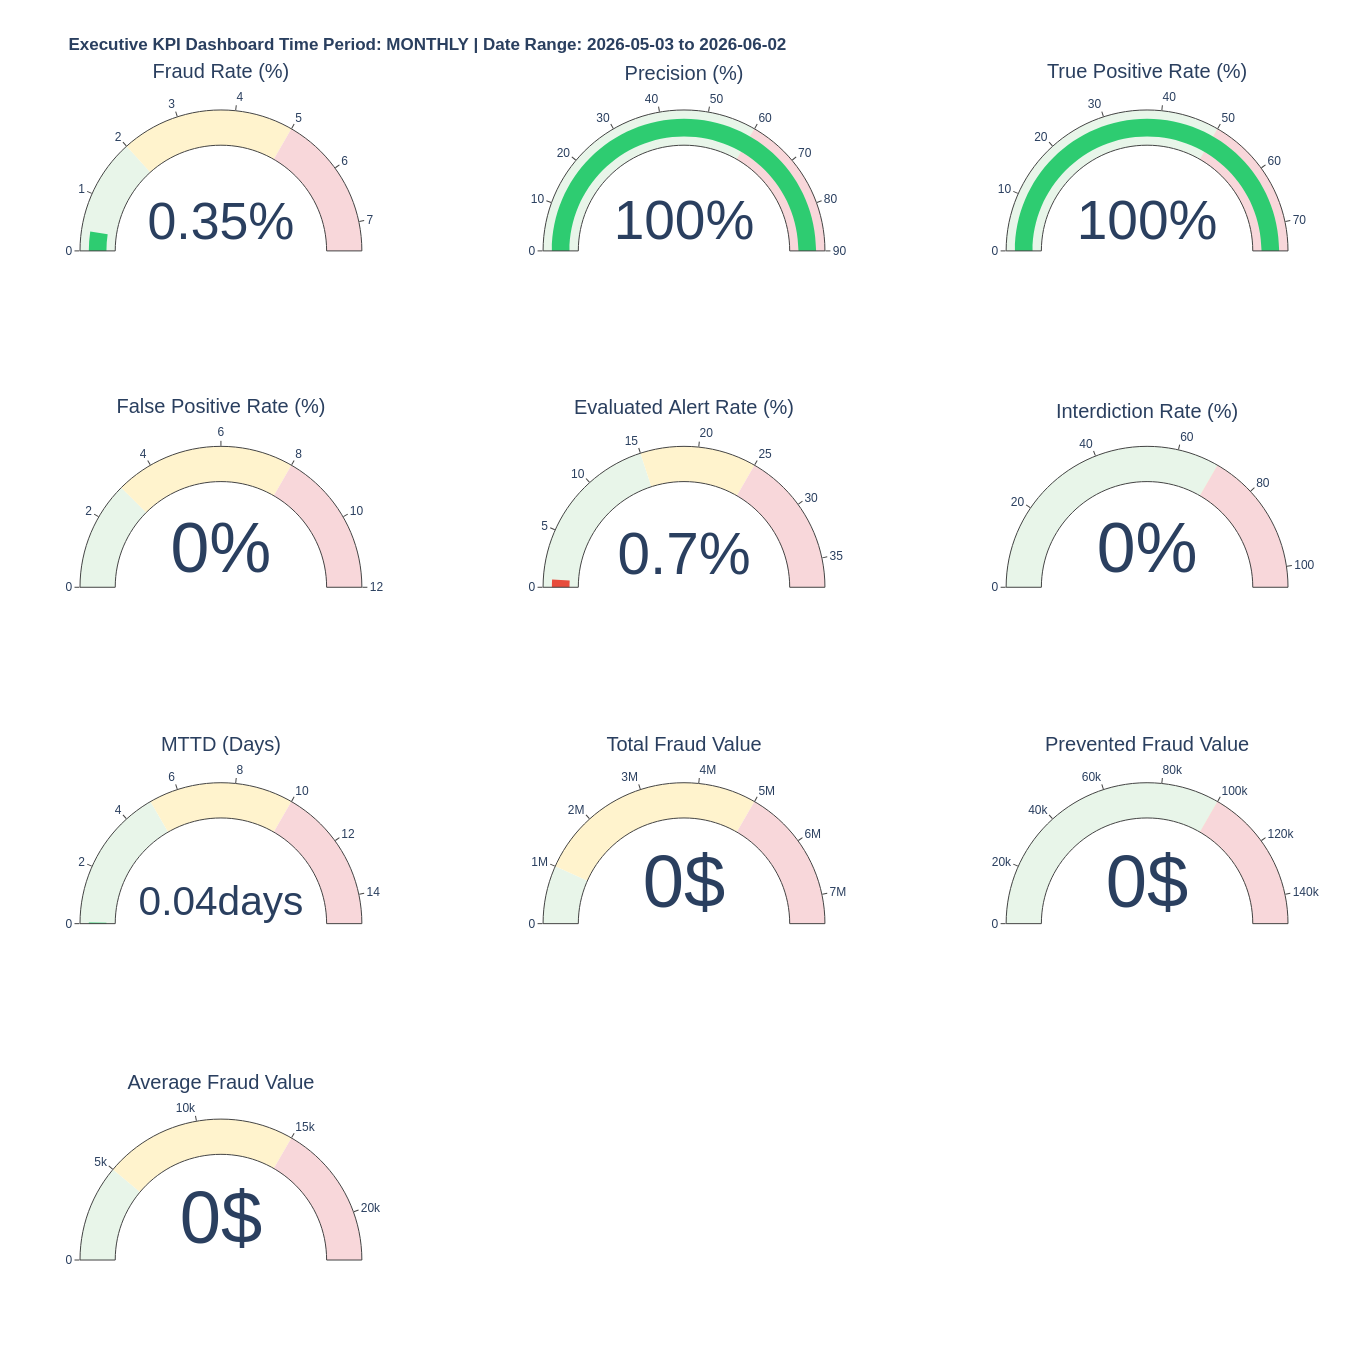

In [44]:
# ============================================================================
# SECTION 8.1: RENDER KPI CARDS (Executive Key Performance Indicators)
# ============================================================================

# Create a dashboard with KPI cards (3x4 grid)
fig_kpis = go.Figure()

# Define KPIs with current values, thresholds, and status
kpis = [
    {
        'title': 'Fraud Rate (%)',
        'value': current_fraud_rate,
        'unit': '%',
        'threshold_good': 2.0,
        'threshold_fair': 5.0,
        'higher_is_better': False
    },
    {
        'title': 'Precision (%)',
        'value': current_precision,
        'unit': '%',
        'threshold_good': 80.0,
        'threshold_fair': 60.0,
        'higher_is_better': True
    },
    {
        'title': 'True Positive Rate (%)',
        'value': current_tpr,
        'unit': '%',
        'threshold_good': 75.0,
        'threshold_fair': 50.0,
        'higher_is_better': True
    },
    {
        'title': 'False Positive Rate (%)',
        'value': current_fpr,
        'unit': '%',
        'threshold_good': 3.0,
        'threshold_fair': 8.0,
        'higher_is_better': False
    },
    {
        'title': 'Evaluated Alert Rate (%)',
        'value': current_evaluated_alert_rate,
        'unit': '%',
        'threshold_good': 15.0,
        'threshold_fair': 25.0,
        'higher_is_better': True
    },
    {
        'title': 'Interdiction Rate (%)',
        'value': current_interdiction_rate,
        'unit': '%',
        'threshold_good': 85.0,
        'threshold_fair': 70.0,
        'higher_is_better': True
    },
    {
        'title': 'MTTD (Days)',
        'value': current_mttd,
        'unit': 'days',
        'threshold_good': 5.0,
        'threshold_fair': 10.0,
        'higher_is_better': False
    },
    {
        'title': 'Total Fraud Value',
        'value': current_total_fraud_value,
        'unit': '$',
        'threshold_good': 1000000,
        'threshold_fair': 5000000,
        'higher_is_better': False
    },
    {
        'title': 'Prevented Fraud Value',
        'value': current_prevented_value,
        'unit': '$',
        'threshold_good': 500000,
        'threshold_fair': 100000,
        'higher_is_better': True
    },
    {
        'title': 'Average Fraud Value',
        'value': current_avg_fraud_value,
        'unit': '$',
        'threshold_good': 5000,
        'threshold_fair': 15000,
        'higher_is_better': False
    },
]

# Create KPI indicators using plotly indicators
fig_kpis = make_subplots(
    rows=4, cols=3,
    specs=[[{'type': 'indicator'}] * 3] * 4,
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

for idx, kpi in enumerate(kpis):
    row = (idx // 3) + 1
    col = (idx % 3) + 1
    
    # Determine status color
    if kpi['higher_is_better']:
        if kpi['value'] >= kpi['threshold_good']:
            color = '#2ecc71'  # Green
        elif kpi['value'] >= kpi['threshold_fair']:
            color = '#f39c12'  # Orange
        else:
            color = '#e74c3c'  # Red
    else:
        if kpi['value'] <= kpi['threshold_good']:
            color = '#2ecc71'  # Green
        elif kpi['value'] <= kpi['threshold_fair']:
            color = '#f39c12'  # Orange
        else:
            color = '#e74c3c'  # Red
    
    fig_kpis.add_trace(
        go.Indicator(
            mode="number+gauge",
            value=kpi['value'],
            title={'text': kpi['title']},
            gauge={
                'axis': {'range': [0, kpi['threshold_fair'] * 1.5]},
                'bar': {'color': color},
                'steps': [
                    {'range': [0, kpi['threshold_good']], 'color': "#e8f5e9"},
                    {'range': [kpi['threshold_good'], kpi['threshold_fair']], 'color': "#fff3cd"},
                    {'range': [kpi['threshold_fair'], kpi['threshold_fair'] * 1.5], 'color': "#f8d7da"},
                ],
            },
            number={'suffix': kpi['unit']},
        ),
        row=row, col=col
    )

fig_kpis.update_layout(
    title_text=f"<b>Executive KPI Dashboard Time Period: {time_granularity.upper()} | Date Range: {dashboard_start_date.strftime('%Y-%m-%d')} to {dashboard_end_date.strftime('%Y-%m-%d')}</sub>",
    showlegend=False,
    height=1350,
    width=1400
)

print("✓ KPI Cards visualization created (4x3 grid with 10 metrics)")
print("  Status indicators: 🟢 Good | 🟡 Fair | 🔴 Poor")

# Display the figure
fig_kpis.show()



VISUALIZATION: TIME-SERIES TRENDS
✓ Time-series trend charts created (3 subplots with 10 metrics)
  Metrics tracked: Fraud Detection, Alert Processing, Financial Impact


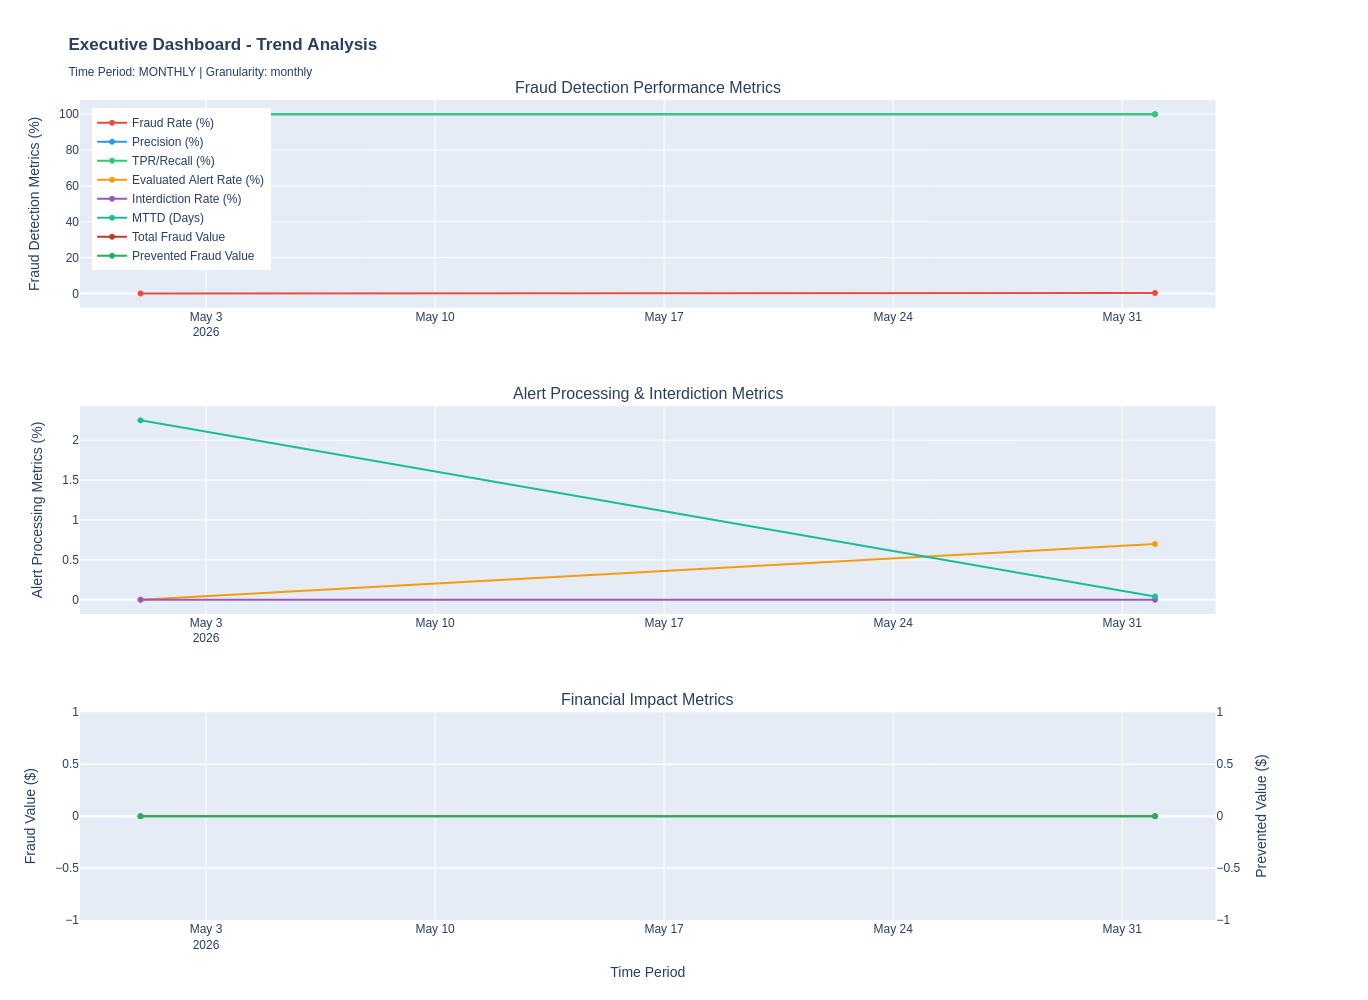

In [32]:
# ============================================================================
# SECTION 8.2: RENDER TIME-SERIES CHARTS (Trends Over Time)
# ============================================================================

print("\n" + "="*80)
print("VISUALIZATION: TIME-SERIES TRENDS")
print("="*80)

# Create 3 time-series subplots
fig_trends = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        "Fraud Detection Performance Metrics",
        "Alert Processing & Interdiction Metrics",
        "Financial Impact Metrics"
    ),
    specs=[
        [{"secondary_y": False}],
        [{"secondary_y": False}],
        [{"secondary_y": True}]
    ],
    vertical_spacing=0.12
)

# CHART 1: Fraud Performance Metrics
fig_trends.add_trace(
    go.Scatter(
        x=fraud_perf_pd['period'],
        y=fraud_perf_pd['fraud_rate_pct'],
        name='Fraud Rate (%)',
        mode='lines+markers',
        line=dict(color='#e74c3c', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

fig_trends.add_trace(
    go.Scatter(
        x=fraud_perf_pd['period'],
        y=fraud_perf_pd['precision_calc'],
        name='Precision (%)',
        mode='lines+markers',
        line=dict(color='#3498db', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

fig_trends.add_trace(
    go.Scatter(
        x=fraud_perf_pd['period'],
        y=fraud_perf_pd['tpr_calc'],
        name='TPR/Recall (%)',
        mode='lines+markers',
        line=dict(color='#2ecc71', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

# CHART 2: Alert Processing Metrics
fig_trends.add_trace(
    go.Scatter(
        x=alert_perf_pd['period'],
        y=alert_perf_pd['evaluated_alert_rate_calc'],
        name='Evaluated Alert Rate (%)',
        mode='lines+markers',
        line=dict(color='#f39c12', width=2),
        marker=dict(size=6)
    ),
    row=2, col=1
)

fig_trends.add_trace(
    go.Scatter(
        x=alert_perf_pd['period'],
        y=alert_perf_pd['overall_interdiction_rate_pct'],
        name='Interdiction Rate (%)',
        mode='lines+markers',
        line=dict(color='#9b59b6', width=2),
        marker=dict(size=6)
    ),
    row=2, col=1
)

fig_trends.add_trace(
    go.Scatter(
        x=case_perf_pd['period'],
        y=case_perf_pd['mttd_days'],
        name='MTTD (Days)',
        mode='lines+markers',
        line=dict(color='#1abc9c', width=2),
        marker=dict(size=6)
    ),
    row=2, col=1
)

# CHART 3: Financial Metrics
fig_trends.add_trace(
    go.Scatter(
        x=financial_pd['period'],
        y=financial_pd['total_fraud_value'],
        name='Total Fraud Value',
        mode='lines+markers',
        line=dict(color='#c0392b', width=2),
        marker=dict(size=6)
    ),
    row=3, col=1, secondary_y=False
)

fig_trends.add_trace(
    go.Scatter(
        x=financial_pd['period'],
        y=financial_pd['prevented_fraud_value_calc'],
        name='Prevented Fraud Value',
        mode='lines+markers',
        line=dict(color='#27ae60', width=2),
        marker=dict(size=6)
    ),
    row=3, col=1, secondary_y=True
)

# Update axes labels
fig_trends.update_yaxes(title_text="Fraud Detection Metrics (%)", row=1, col=1)
fig_trends.update_yaxes(title_text="Alert Processing Metrics (%)", row=2, col=1)
fig_trends.update_yaxes(title_text="Fraud Value ($)", row=3, col=1, secondary_y=False)
fig_trends.update_yaxes(title_text="Prevented Value ($)", row=3, col=1, secondary_y=True)
fig_trends.update_xaxes(title_text="Time Period", row=3, col=1)

fig_trends.update_layout(
    title_text=f"<b>Executive Dashboard - Trend Analysis</b><br><sub>Time Period: {time_granularity.upper()} | Granularity: {time_granularity}</sub>",
    height=1000,
    width=1400,
    hovermode='x unified',
    showlegend=True,
    legend=dict(x=0.01, y=0.99)
)

print("✓ Time-series trend charts created (3 subplots with 10 metrics)")
print("  Metrics tracked: Fraud Detection, Alert Processing, Financial Impact")

# Display the figure
fig_trends.show()



VISUALIZATION: EXECUTIVE SUMMARY TABLE
✓ Executive summary table created with 10 KPIs
  Columns: Current Value, Previous Period, Trend Direction, % Change


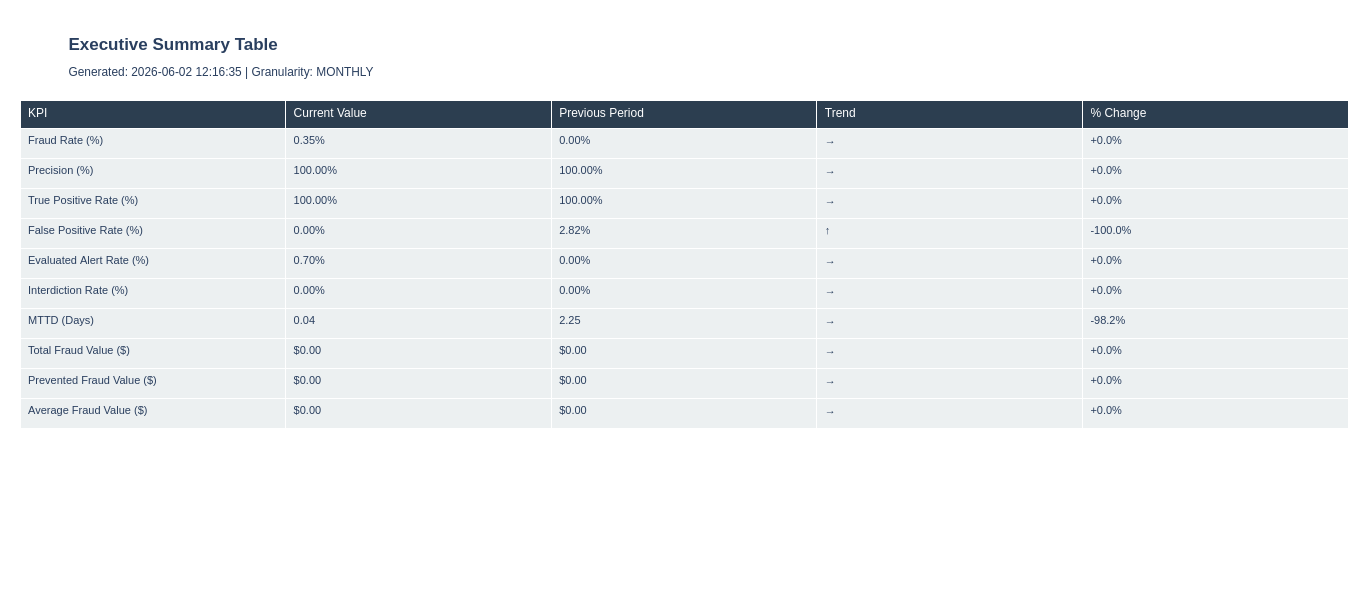

In [35]:
# ============================================================================
# SECTION 8.3: RENDER SUMMARY TABLE (Executive Summary)
# ============================================================================

print("\n" + "="*80)
print("VISUALIZATION: EXECUTIVE SUMMARY TABLE")
print("="*80)

# Create comprehensive summary table
summary_data = {
    'KPI': [
        'Fraud Rate (%)',
        'Precision (%)',
        'True Positive Rate (%)',
        'False Positive Rate (%)',
        'Evaluated Alert Rate (%)',
        'Interdiction Rate (%)',
        'MTTD (Days)',
        'Total Fraud Value ($)',
        'Prevented Fraud Value ($)',
        'Average Fraud Value ($)'
    ],
    'Current Value': [
        f"{current_fraud_rate:.2f}%",
        f"{current_precision:.2f}%",
        f"{current_tpr:.2f}%",
        f"{current_fpr:.2f}%",
        f"{current_evaluated_alert_rate:.2f}%",
        f"{current_interdiction_rate:.2f}%",
        f"{current_mttd:.2f}",
        f"${current_total_fraud_value:,.2f}",
        f"${current_prevented_value:,.2f}",
        f"${current_avg_fraud_value:,.2f}"
    ],
    'Previous Period': [
        f"{fraud_perf_pd['fraud_rate_pct'].iloc[-2]:.2f}%" if len(fraud_perf_pd) >= 2 else "N/A",
        f"{fraud_perf_pd['precision_calc'].iloc[-2]:.2f}%" if len(fraud_perf_pd) >= 2 else "N/A",
        f"{fraud_perf_pd['tpr_calc'].iloc[-2]:.2f}%" if len(fraud_perf_pd) >= 2 else "N/A",
        f"{case_perf_pd['false_positive_rate_pct'].iloc[-2]:.2f}%" if len(case_perf_pd) >= 2 else "N/A",
        f"{alert_perf_pd['evaluated_alert_rate_calc'].iloc[-2]:.2f}%" if len(alert_perf_pd) >= 2 else "N/A",
        f"{alert_perf_pd['overall_interdiction_rate_pct'].iloc[-2]:.2f}%" if len(alert_perf_pd) >= 2 else "N/A",
        f"{case_perf_pd['mttd_days'].iloc[-2]:.2f}" if len(case_perf_pd) >= 2 else "N/A",
        f"${financial_pd['total_fraud_value'].iloc[-2]:,.2f}" if len(financial_pd) >= 2 else "N/A",
        f"${financial_pd['prevented_fraud_value_calc'].iloc[-2]:,.2f}" if len(financial_pd) >= 2 else "N/A",
        f"${financial_pd['average_fraud_value'].iloc[-2]:,.2f}" if len(financial_pd) >= 2 else "N/A"
    ],
    'Trend': [
        trends_df['fraud_rate_direction'].iloc[-1] if len(trends_df) > 0 and 'fraud_rate_direction' in trends_df.columns else "→",
        trends_df['precision_direction'].iloc[-1] if len(trends_df) > 0 and 'precision_direction' in trends_df.columns else "→",
        trends_df['tpr_direction'].iloc[-1] if len(trends_df) > 0 and 'tpr_direction' in trends_df.columns else "→",
        trends_df['fpr_direction'].iloc[-1] if len(trends_df) > 0 and 'fpr_direction' in trends_df.columns else "→",
        trends_df['idr_direction'].iloc[-1] if len(trends_df) > 0 and 'idr_direction' in trends_df.columns else "→",
        trends_df['idr_direction'].iloc[-1] if len(trends_df) > 0 and 'idr_direction' in trends_df.columns else "→",
        "→",
        trends_df['fraud_value_direction'].iloc[-1] if len(trends_df) > 0 and 'fraud_value_direction' in trends_df.columns else "→",
        trends_df['fraud_value_direction'].iloc[-1] if len(trends_df) > 0 and 'fraud_value_direction' in trends_df.columns else "→",
        trends_df['fraud_value_direction'].iloc[-1] if len(trends_df) > 0 and 'fraud_value_direction' in trends_df.columns else "→",
    ],
    '% Change': [
        f"{trends_df['fraud_rate_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['precision_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['tpr_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['fpr_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['ear_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['idr_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['mttd_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['fraud_value_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['fraud_value_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
        f"{trends_df['fraud_value_change_pct'].iloc[-1]:+.1f}%" if len(trends_df) > 0 else "N/A",
    ]
}

summary_table_df = pd.DataFrame(summary_data)

# Create Plotly table
fig_summary = go.Figure(data=[go.Table(
    header=dict(
        values=list(summary_table_df.columns),
        fill_color='#2c3e50',
        align='left',
        font=dict(color='white', size=12, family="Arial")
    ),
    cells=dict(
        values=[summary_table_df[col] for col in summary_table_df.columns],
        fill_color='#ecf0f1',
        align='left',
        font=dict(size=11, family="Arial"),
        height=30
    )
)])

fig_summary.update_layout(
    title=f"<b>Executive Summary Table</b><br><sub>Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')} | Granularity: {time_granularity.upper()}</sub>",
    height=600,
    width=1400,
    margin=dict(l=20, r=20, t=100, b=20)
)

print("✓ Executive summary table created with 10 KPIs")
print("  Columns: Current Value, Previous Period, Trend Direction, % Change")

# Display the figure
fig_summary.show()